# Wind Loading, Oscillations & Dust Ingression — Operational Wind-Speed Limits

**Question.** How does wind affect the Rubin Observatory telescope as a function of
**wind speed** and **relative wind direction to telescope pointing**, and what are the
resulting **operational wind-speed limits** when pointed *into* vs *away from* the wind?

We treat four physical effects:

1. **Static aerodynamic loading** — wind pushing on the mirrors/telescope: force & moment
   (measured via M1M3 hardpoint forces; modeled via `q = ½ρV²·Cd·A`).
2. **Bulk motion** — actual rigid-body deflection of M1M3 / M2 under wind (IMS telemetry).
3. **Wind-induced oscillations** — the *dynamic* (frequency-domain) response: does wind
   excite structural resonances? (Welch PSDs of the high-rate M1M3 IMS / hardpoint data.)
4. **Dust ingression** — particulate influx through the open shutter/louvers vs wind.

We then anchor **operational wind-speed limits** to **six** metrics and report the
binding (most restrictive) limit for the into-wind and away-from-wind cases:

| # | Anchor metric | Source | What it measures | Budget |
|---|---------------|--------|------------------|--------|
| a | **M1M3 balance moment** (mx,my) | EFD `MTM1M3.appliedBalanceForces` | Wind load on the mirror (force-balance loop response; gravity removed) | +margin vs calm |
| b | Mount tracking jitter | ConsDB `exposure_quicklook` `mount_jitter_rms` | Bulk telescope tracking error [arcsec] | **0.047″ wind allocation** |
| c | Mirror bulk motion (IMS) | EFD `MTM1M3.imsData`, `MTM2.positionIMS` | Physical optic deflection | +margin vs calm |
| d | PSF FWHM | ConsDB `visit1_quicklook` | End-to-end delivered image quality | +margin vs calm |
| d2 | Donut blur FWHM | ConsDB `visit1_quicklook` `donut_blur_fwhm` | Out-of-focus blur (AOS/defocus proxy) | +margin vs calm |
| e | Guider RMS motion | ConsDB `visit1_quicklook` (mas→arcsec) | Direct in-exposure image motion [arcsec], seeing-independent | **0.047″ wind allocation** |

> **Force anchor note.** We anchor on the M1M3 **balance moment**, not the raw hardpoint
> forces: the force-balance loop drives the hardpoint loads to ~zero, so the HP forces are
> the loop *error residual* (dominated by slew-settle transients), whereas the balance
> moment is what the loop *applies* to resist the wind disturbance. Per-exposure statistics
> skip the first 5 s (slew-settle) and use the native ~50 Hz rate.
>
> **Tracking-jitter budget.** The mount jitter and guider RMS anchors use the
> **wind-buffeting jitter allocation (< 0.047″)** — the portion of the total 0.01″
> tracking-jitter design requirement allocated to wind (the 0.01″ requirement covers all
> error sources: servo, encoder, thermal, wind). Since this analysis isolates the wind
> contribution, 0.047″ is the correct budget; the 0.01″ requirement is shown for context.
> Guider magnitude RMS is converted mas→arcsec. Other anchors use data-informed relative
> budgets (§19).

**Structure — three explicitly separated evidence layers:**
- **Layer A (§10–§15):** measured telemetry, per science exposure.
- **Layer B (§16–§18):** first-principles aerodynamic model, *validated against Layer A*.
- **Layer C (§19–§22):** synthesis → two-sided operational limits + recommendations.

**Relative-wind convention (the split axis for the whole analysis):**
`relative_wind = wrap180(wind_direction − dome_azimuth)`.
**0° = pointed INTO the wind** (wind arrives from the dome-opening direction);
**±180° = pointed AWAY** (dome shields the aperture). We define
`into_wind = |relative_wind| < 45°` and `away_wind = |relative_wind| > 135°`; the
45–135° crosswind band is retained for context but excluded from the two-sided split.

> ⚠️ **All aerodynamic-model numbers (Cd, projected area, lever arm) are labeled
> ASSUMPTION in-cell** and are stress-tested in the sensitivity analysis (§21). The
> operational limits are driven primarily by *measured* telemetry; the model is used to
> interpret and to extrapolate beyond the observed wind-speed range.

Reuses the ConsDB+EFD machinery from `optical_psf/ConsDB_EFD_to_PSF_Effects_Diagnosis.ipynb`
and the dome/wind conventions from `dome_and_wind/ESS_Wind_vs_DomePointing.ipynb` and
`Dome_Flow_Estimation.ipynb`.

## §1 — Imports

In [1]:
import os
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import sqlalchemy

from scipy import signal, stats
from scipy import stats as spstats  # alias: `stats` is reused as a local var in the mirror-stats join

from astropy.time import Time, TimeDelta
import astropy.units as u

from lsst_efd_client import EfdClient

warnings.filterwarnings("ignore", category=RuntimeWarning)  # nan-slices in binned stats
%matplotlib inline
pd.set_option("display.max_columns", 60)

## §2 — Configuration

Single control cell. The `VALIDATE_WINDOW` toggle switches between a short recent window
(fast, for building/validating) and the full 25-week window. `day_obs_start/end` and the
cache filename are derived **after** the toggle so ConsDB, EFD, and the cache stay
mutually consistent — the validate and full runs write to distinct cache files keyed by
`day_obs`, so they never collide.

In [2]:
# ── ConsDB / PostgreSQL (verbatim from ConsDB_EFD_to_PSF_Effects_Diagnosis.ipynb) ──
PGPASS_FILE  = os.path.expanduser("~/.lsst/postgres-credentials.txt")
CONSDB_HOST  = "usdf-summitdb-logical-replica-svc.sdf.slac.stanford.edu"
CONSDB_DB    = "exposurelog"
CONSDB_USER  = "usdf"
SCHEMA       = "cdb_lsstcam"

def load_pgpass(path, host, database, user):
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            parts = line.split(":")
            if len(parts) < 5:
                continue
            h, db, u_ = parts[0], parts[2], parts[3]
            pwd = ":".join(parts[4:])
            if h == host and db == database and u_ == user:
                return pwd
    raise ValueError(f"No credentials for {user}@{host}/{database}")

db_pass = load_pgpass(PGPASS_FILE, CONSDB_HOST, CONSDB_DB, CONSDB_USER)
engine = sqlalchemy.create_engine(
    f"postgresql+psycopg2://{CONSDB_USER}:{db_pass}@{CONSDB_HOST}/{CONSDB_DB}",
    connect_args={"connect_timeout": 30},
)

def consdb_query(sql):
    with engine.connect() as conn:
        return pd.read_sql_query(sqlalchemy.text(sql), conn)

print("ConsDB schemas:")
display(consdb_query(
    "SELECT schema_name FROM information_schema.schemata "
    "WHERE schema_name LIKE 'cdb_%' ORDER BY 1"
))

ConsDB schemas:


,schema_name
0,cdb_latiss
1,cdb_lsstcam
2,cdb_lsstcomcam
3,cdb_lsstcomcamsim
4,cdb_startrackerfast
5,cdb_startrackernarrow
6,cdb_startrackerwide


In [3]:
# ── Time window ──────────────────────────────────────────────────────────────
# LSSTCam science exposures in ConsDB run through 2026-04-27 (survey pause; only
# darks/flats exist afterward, and those are dome-closed → filtered out by the
# open-dome guard in §9). The full analysis window is anchored to a literal
# calendar end of 2026-07-01, 25 weeks back (2026-01-07 → 2026-07-01): this
# contains 36,425 science exposures across 73 nights (all 2026-01-07..2026-04-27).
# Set ANCHOR_TO_LAST_DATA=True to instead anchor t_end to the last science night
# (2026-04-27), which slides the 25-week window back to capture the Nov-2025
# science nights as well.
ANCHOR_TO_LAST_DATA = False

def _last_science_day():
    r = consdb_query(f"SELECT max(day_obs) AS mx FROM {SCHEMA}.exposure WHERE img_type='science'")
    return int(r.iloc[0, 0])

if ANCHOR_TO_LAST_DATA:
    _mx = _last_science_day()
    _s  = str(_mx)
    t_end = Time(f"{_s[:4]}-{_s[4:6]}-{_s[6:8]}T12:00:00", scale="utc") + TimeDelta(1*u.day)
    print(f"anchored t_end to last science day_obs={_mx}")
else:
    t_end = Time("2026-07-01T12:00:00", scale="utc")

FULL_WEEKS = 25

# VALIDATE_WINDOW=True → short recent window to build & sanity-check the notebook.
# Flip to False for the full 25-week window (fetched via the standalone cache
# builder build_full_cache.py; the notebook then just loads that cache).
VALIDATE_WINDOW = False
VALIDATE_WEEKS  = 2

_weeks  = VALIDATE_WEEKS if VALIDATE_WINDOW else FULL_WEEKS
t_start = t_end - TimeDelta(_weeks * u.week)

day_obs_start = int(t_start.strftime("%Y%m%d"))
day_obs_end   = int(t_end.strftime("%Y%m%d"))

print(f"{'VALIDATE' if VALIDATE_WINDOW else 'FULL'} window: {_weeks} weeks")
print(f"  {t_start.iso}  →  {t_end.iso}")
print(f"  day_obs {day_obs_start} → {day_obs_end}")

# ── Parquet cache (filename encodes the window) ──────────────────────────────
CACHE_DIR   = pathlib.Path("../data")
CACHE_FILE  = CACHE_DIR / f"wind_loading_{day_obs_start}_{day_obs_end}.parquet"
PSD_CACHE_FILE = CACHE_DIR / f"wind_loading_psd_{day_obs_start}_{day_obs_end}.parquet"
FORCE_REFETCH        = False
INCREMENTAL_REFETCH  = False
print(f"\ncache: {CACHE_FILE}")

FULL window: 25 weeks
  2026-01-07 12:00:00.000  →  2026-07-01 12:00:00.000
  day_obs 20260107 → 20260701

cache: ../data/wind_loading_20260107_20260701.parquet


In [4]:
# ── EFD topics / indices ─────────────────────────────────────────────────────
EFD_ALIAS         = "usdf_efd"

flow_topic        = "lsst.sal.ESS.airFlow"          # outside wind
turb_topic        = "lsst.sal.ESS.airTurbulence"    # inside dome turbulence
dome_topic        = "lsst.sal.MTDome.azimuth"       # dome azimuth
shutter_topic     = "lsst.sal.MTDome.apertureShutter"
pressure_topic    = "lsst.sal.ESS.pressure"         # for air density
particle_topic    = "lsst.sal.ESS.particleMeasurements"  # dust
weather_index     = 301                             # outside weather station
pressure_index    = 301
shutter_threshold = 95.0                            # % open

# Mount actual pointing (field name confirmed live in §4)
mount_el_topic    = "lsst.sal.MTMount.elevation"
mount_az_topic    = "lsst.sal.MTMount.azimuth"
MOUNT_POS_FIELD   = "actualPosition"                # verified/overridden in §4

ess_sensors = {
    110: "TMA Platform",
    123: "Top Ring -X/-Y",
    124: "Top Ring +X/-Y",
    125: "Top Ring +X/+Y",
    126: "Top Ring -X/+Y",
}
# saturation clip (m/s): top-ring sensors saturate ~8.6 m/s; TMA platform unclipped
speed_clip = {110: None, 123: 8.6, 124: 8.6, 125: 8.6, 126: 8.6}

particle_indices = {127: "Dome PM A", 128: "Dome PM B", 129: "Dome PM C"}

# High-rate mirror / force telemetry (per-exposure mean/std + spectral)
mirror_topics = {
    "m1m3ims": {"topic": "lsst.sal.MTM1M3.imsData",
                "fields": ["xPosition", "yPosition", "zPosition",
                           "xRotation", "yRotation", "zRotation"]},
    "m1m3hp":  {"topic": "lsst.sal.MTM1M3.hardpointActuatorData",
                "fields": [f"measuredForce{i}" for i in range(6)]},
    # appliedBalanceForces: force-balance loop's aggregate force/moment. The balance
    # MOMENTS (mx,my) are the physical wind-load signal (gravity is carried by the
    # static support); HP forces are the loop error residual (≈0 steady-state) and are
    # kept only for diagnostic comparison. Balance mx,my give the moment directly.
    "m1m3bal": {"topic": "lsst.sal.MTM1M3.appliedBalanceForces",
                "fields": ["fx", "fy", "fz", "mx", "my", "mz"]},
    "m2pos":   {"topic": "lsst.sal.MTM2.positionIMS",
                "fields": ["x", "y", "z", "xRot", "yRot", "zRot"]},
}

# Skip the first N s of each exposure window: the mount has just finished slewing and
# the M1M3 support is still ringing down — those forces are slew-settle transients, not
# wind loading (verified: dynamic RMS ~halves when the leading 5 s is dropped).
SETTLE_SKIP_S = 5.0

In [5]:
# ── Binning idioms (match sibling dome/wind notebooks) ───────────────────────
wind_speed_bins   = [0, 3, 6, 9, 12, np.inf]
wind_speed_labels = ["0-3", "3-6", "6-9", "9-12", ">12"]
wind_speed_colors = ["steelblue", "mediumseagreen", "goldenrod", "tomato", "mediumpurple"]

rel_wind_bins   = np.arange(-180, 181, 15)          # 15° relative-wind bins
speed_fit_bins  = np.arange(0, 20.1, 1.0)           # 1 m/s bins for limit fits

INTO_WIND_MAX = 45.0    # |rel_wind| < this  → pointed into the wind
AWAY_WIND_MIN = 135.0   # |rel_wind| > this  → pointed away from the wind

# ── Aerodynamic model constants — ALL ASSUMPTIONS (stress-tested in §21) ─────
R_AIR       = 287.1     # J/(kg·K) dry-air gas constant
RHO_REF     = 0.80      # kg/m³ fallback air density at Cerro Pachón (~2650 m, ~5°C)
A_M1M3      = 55.0      # m²  face-on projected area of the 8.4 m primary  [ASSUMPTION]
CD_MIRROR   = 1.2       # flat-plate normal drag coefficient               [ASSUMPTION]
CD_RANGE    = (1.1, 1.3)
LEVER_ARM_M = 2.0       # m   elevation-axis → M1M3 centre-of-pressure      [ASSUMPTION]
SHUTTER_OPEN_AREA = 200.0   # m²  full-open aperture (no LWS)
DOME_DIAMETER     = 30.0    # m

# ── Operational budgets (anchor thresholds) — set in §19, placeholder here ───
BUDGETS = {}   # populated in §19

# ── Plot helpers ─────────────────────────────────────────────────────────────
def wrap180(a):
    """Wrap angle(s) to [-180, 180] degrees."""
    return ((np.asarray(a, dtype=float) + 180.0) % 360.0) - 180.0

def to_epoch(ts):
    """pandas DatetimeIndex → seconds since epoch (for np.interp)."""
    return ts.astype(np.int64) / 1e9

def circular_mean_deg(x):
    x_rad = np.deg2rad(pd.Series(x).dropna())
    if len(x_rad) == 0:
        return np.nan
    return np.rad2deg(np.arctan2(np.sin(x_rad).mean(), np.cos(x_rad).mean())) % 360

# mount jitter / image-degradation physical clip [arcsec]
MOUNT_JITTER_MIN = 0.0
MOUNT_JITTER_MAX = 1.0

print("config loaded")

config loaded


## §3 — Cache short-circuit

If a cache for this exact window exists (and `FORCE_REFETCH` is off), load it and set
`_from_cache=True`. Every fetch/compute cell below is guarded by `if not _from_cache:`,
so re-runs — and the eventual full 25-week run once its cache is built — are fast.

In [6]:
_from_cache = False
if not FORCE_REFETCH and CACHE_FILE.exists():
    df_joined = pd.read_parquet(CACHE_FILE)
    _from_cache = True
    print(f"✓ Loaded {len(df_joined):,} rows from cache: {CACHE_FILE}")
    print(f"  {df_joined.index.min()} → {df_joined.index.max()}")
elif FORCE_REFETCH:
    print("FORCE_REFETCH=True — bypassing cache")
else:
    print(f"No cache at {CACHE_FILE} — will fetch fresh data")

✓ Loaded 36,425 rows from cache: ../data/wind_loading_20260107_20260701.parquet
  2026-01-08 02:05:28.125000+00:00 → 2026-04-28 07:11:31.368000+00:00


## §4 — Schema & live-data probes  *(verification)*

Concentrates all "needs live verification" items before the expensive fetch:
- ConsDB `img_type` counts, date range, and quicklook coverage in-window.
- Guider RMS/drift column names in `visit1_quicklook` (via `information_schema`).
- EFD topic/field probes: `MTMount.elevation` field name, M1M3 IMS/HP **sample rate**
  (sets the §13b PSD Nyquist band), M2, `particleMeasurements` 127/128/129 (may be
  empty — dust sensors are intermittently deployed), `ESS.pressure` 301.

Prints a go/no-go checklist. Safe to run even when `_from_cache=True` (read-only).

In [7]:
# ConsDB coverage
print("img_type counts:")
display(consdb_query(f"""
    SELECT img_type, count(*) AS n FROM {SCHEMA}.exposure
    GROUP BY img_type ORDER BY n DESC LIMIT 8
"""))
print("science + quicklook coverage in-window:")
display(consdb_query(f"""
    SELECT
      count(*) AS n_science,
      count(q.visit_id) AS n_visit1_quicklook,
      count(m.day_obs)  AS n_exposure_quicklook
    FROM {SCHEMA}.exposure e
    LEFT JOIN {SCHEMA}.visit1_quicklook  q ON q.day_obs=e.day_obs AND q.seq_num=e.seq_num
    LEFT JOIN {SCHEMA}.exposure_quicklook m ON m.day_obs=e.day_obs AND m.seq_num=e.seq_num
    WHERE e.img_type='science' AND e.day_obs BETWEEN {day_obs_start} AND {day_obs_end}
"""))

img_type counts:


,img_type,n
0,science,69950
1,acq,34735
2,flat,29995
3,dark,13926
4,bias,13375
5,cwfs,6834
6,engtest,2065
7,focus,176


science + quicklook coverage in-window:


,n_science,n_visit1_quicklook,n_exposure_quicklook
0,36425,36315,15110


In [8]:
# Discover guider RMS / drift columns in visit1_quicklook
guider_cols_df = consdb_query(f"""
    SELECT column_name, data_type FROM information_schema.columns
    WHERE table_schema='{SCHEMA}' AND table_name='visit1_quicklook'
      AND column_name ILIKE '%guider%'
    ORDER BY ordinal_position
""")
print(f"{len(guider_cols_df)} guider columns in visit1_quicklook:")
display(guider_cols_df)

# Candidate guider columns we want (intersect with what actually exists)
GUIDER_WANT = [
    "guider_altitude_drift", "guider_azimuth_drift", "guider_magnitude_drift",
    "guider_altitude_rms_detrended", "guider_azimuth_rms_detrended",
    "guider_magnitude_rms_detrended",
    "guider_focalplane_theta_drift", "guider_focalplane_theta_rms_detrended",
]
_avail = set(guider_cols_df["column_name"])
GUIDER_COLS = [c for c in GUIDER_WANT if c in _avail]
print(f"\nUsing guider columns: {GUIDER_COLS}")
if not GUIDER_COLS:
    print("⚠ no expected guider columns present — anchor (e) will be unavailable")

31 guider columns in visit1_quicklook:


,column_name,data_type
0,guider_exp_time,double precision
1,guider_n_tracked_stars,integer
2,guider_n_measurements,integer
3,guider_altitude_drift,double precision
4,guider_altitude_standard_deviation,double precision
5,guider_altitude_rms_detrended,double precision
6,guider_azimuth_drift,double precision
7,guider_azimuth_standard_deviation,double precision
8,guider_azimuth_rms_detrended,double precision
9,guider_focalplane_theta_drift,double precision



Using guider columns: ['guider_altitude_drift', 'guider_azimuth_drift', 'guider_magnitude_drift', 'guider_altitude_rms_detrended', 'guider_azimuth_rms_detrended', 'guider_magnitude_rms_detrended', 'guider_focalplane_theta_drift', 'guider_focalplane_theta_rms_detrended']


In [9]:
# EFD probes — use select_time_series directly (schema registry not reachable
# from SDF; get_schema() fails but data fetches work). Short 2-hour window.
efd_client = EfdClient(EFD_ALIAS)
print("Connected to EFD\n")

t_probe_end = t_start + TimeDelta(2 * u.hour)

async def probe(topic, fields, index=None):
    try:
        df = await efd_client.select_time_series(
            topic, fields=fields, start=t_start, end=t_probe_end, index=index)
        dt = np.median(np.diff(df.index.astype(np.int64)/1e9)) if len(df) > 3 else np.nan
        rate = 1.0/dt if (dt == dt and dt > 0) else np.nan
        print(f"  {topic}{f' [idx={index}]' if index is not None else ''}: "
              f"rows/2h={len(df)}  ~{rate:.1f} Hz  cols={list(df.columns)[:6]}")
        return df, rate
    except Exception as e:
        print(f"  {topic}  → {str(e)[:90]}")
        return None, np.nan

print("── Mount pointing ──")
_df_el, _ = await probe(mount_el_topic, [MOUNT_POS_FIELD])
if _df_el is None:
    # resolve the field name if the default is wrong
    for cand in ("positionActual", "actualPositionTimestamp"):
        _df_el, _ = await probe(mount_el_topic, [cand])
        if _df_el is not None:
            MOUNT_POS_FIELD = cand
            print(f"    → MOUNT_POS_FIELD resolved to '{MOUNT_POS_FIELD}'"); break

print("\n── High-rate mirror / force (sets §13b PSD band) ──")
_ims_df, IMS_RATE = await probe(mirror_topics["m1m3ims"]["topic"], ["xPosition", "zPosition"])
_hp_df,  HP_RATE  = await probe(mirror_topics["m1m3hp"]["topic"],  ["measuredForce0"])
_m2_df,  M2_RATE  = await probe(mirror_topics["m2pos"]["topic"],   ["x", "z"])

print("\n── Environment / dust ──")
_p_df, _  = await probe(pressure_topic, ["pressureItem0"], index=pressure_index)
_w_df, _  = await probe(flow_topic, ["speed", "direction"], index=weather_index)
PARTICLE_OK = {}
for idx, lab in particle_indices.items():
    dfp, _ = await probe(particle_topic, ["numberConcentration0"], index=idx)
    PARTICLE_OK[idx] = (dfp is not None and len(dfp) > 0)

print("\n──────── GO/NO-GO CHECKLIST ────────")
print(f"  guider anchor (e)     : {'OK' if GUIDER_COLS else 'MISSING'}")
print(f"  mount pos field       : {MOUNT_POS_FIELD} ({'OK' if _df_el is not None else 'CHECK'})")
print(f"  IMS / HP / M2 rate Hz : {IMS_RATE:.0f} / {HP_RATE:.0f} / {M2_RATE:.0f}")
print(f"  pressure (ρ)          : {'OK' if _p_df is not None and len(_p_df) else 'FALLBACK RHO_REF'}")
print(f"  outside wind          : {'OK' if _w_df is not None and len(_w_df) else 'MISSING'}")
print(f"  particle (dust)       : {PARTICLE_OK}")

Connected to EFD

── Mount pointing ──


  lsst.sal.MTMount.elevation: rows/2h=126804  ~20.0 Hz  cols=['actualPosition']

── High-rate mirror / force (sets §13b PSD band) ──


  lsst.sal.MTM1M3.imsData: rows/2h=297308  ~49.6 Hz  cols=['xPosition', 'zPosition']


  lsst.sal.MTM1M3.hardpointActuatorData: rows/2h=355429  ~49.8 Hz  cols=['measuredForce0']


  lsst.sal.MTM2.positionIMS: rows/2h=144000  ~20.0 Hz  cols=['x', 'z']

── Environment / dust ──
  lsst.sal.ESS.pressure [idx=301]: rows/2h=1875  ~0.3 Hz  cols=['pressureItem0']
  lsst.sal.ESS.airFlow [idx=301]: rows/2h=5625  ~0.8 Hz  cols=['speed', 'direction']
  lsst.sal.ESS.particleMeasurements [idx=127]: rows/2h=0  ~nan Hz  cols=[]
  lsst.sal.ESS.particleMeasurements [idx=128]: rows/2h=0  ~nan Hz  cols=[]
  lsst.sal.ESS.particleMeasurements [idx=129]: rows/2h=0  ~nan Hz  cols=[]

──────── GO/NO-GO CHECKLIST ────────
  guider anchor (e)     : OK
  mount pos field       : actualPosition (OK)
  IMS / HP / M2 rate Hz : 50 / 50 / 20
  pressure (ρ)          : OK
  outside wind          : OK
  particle (dust)       : {127: False, 128: False, 129: False}


## §5 — Fetch science exposures + quicklook (ConsDB)

One row per science exposure: pointing, ConsDB wind summary, PSF/AOS, mount jitter, and
the guider RMS/drift columns (anchor e). Guider columns are injected dynamically from the
`GUIDER_COLS` list resolved in §4, so the query adapts to what the schema actually has.

In [10]:
if not _from_cache:
    _guider_sql = (",\n            " + ",\n            ".join(f"q.{c}" for c in GUIDER_COLS)
                   if GUIDER_COLS else "")
    df_exp = consdb_query(f"""
        SELECT
            e.exposure_id, e.day_obs, e.seq_num, e.obs_start, e.obs_start_mjd, e.exp_time,
            e.airmass, e.s_ra, e.s_dec, e.azimuth, e.altitude, e.sky_rotation,
            e.wind_speed, e.wind_dir, e.dimm_seeing, e.air_temp, e.humidity,
            e.band, e.physical_filter, e.target_name, e.img_type,
            e.vignette, e.can_see_sky, e.scheduler_note,
            q.psf_sigma_median, q.seeing_zenith_500nm_median, q.eff_time_median,
            q.eff_time_zero_point_scale_median, q.sky_bg_median, q.zero_point_median,
            q.donut_blur_fwhm, q.aos_fwhm,
            q.z4, q.z5, q.z6, q.z7, q.z8, q.z9, q.z10, q.z11,
            q.psf_ixx_median, q.psf_iyy_median, q.psf_ixy_median{_guider_sql},
            m.mount_motion_image_degradation, m.mount_motion_image_degradation_az,
            m.mount_motion_image_degradation_el, m.mount_motion_image_degradation_rot,
            m.mount_jitter_rms, m.mount_jitter_rms_az,
            m.mount_jitter_rms_el, m.mount_jitter_rms_rot
        FROM {SCHEMA}.exposure e
        LEFT JOIN {SCHEMA}.visit1_quicklook  q ON q.day_obs=e.day_obs AND q.seq_num=e.seq_num
        LEFT JOIN {SCHEMA}.exposure_quicklook m ON m.day_obs=e.day_obs AND m.seq_num=e.seq_num
        WHERE e.day_obs BETWEEN {day_obs_start} AND {day_obs_end}
          AND e.img_type='science'
        ORDER BY e.obs_start_mjd
    """)
    df_exp["obs_start_utc"] = pd.to_datetime(df_exp["obs_start"], utc=True)
    df_exp = df_exp.sort_values("obs_start_utc").set_index("obs_start_utc")
    print(f"Science exposures : {len(df_exp)}")
    print(f"  date range      : {df_exp.index.min()} → {df_exp.index.max()}")
    print(f"  with PSF sigma  : {df_exp['psf_sigma_median'].notna().sum()}")
    print(f"  with AOS FWHM   : {df_exp['aos_fwhm'].notna().sum()}")
    print(f"  with mount jit  : {df_exp['mount_jitter_rms'].notna().sum()}")
    if GUIDER_COLS:
        print(f"  with guider RMS : {df_exp[GUIDER_COLS[0]].notna().sum()} ({GUIDER_COLS[0]})")
    display(df_exp.head(3))

## §6 — Fetch EFD telemetry  *(async, daily-chunked)*

All raw series pulled once. `fetch_chunked` splits into daily pieces to stay under the
EFD row limit — **mandatory** for the high-rate M1M3 IMS/hardpoint topics. Empty results
(e.g. dust sensors) are tolerated gracefully.

In [11]:
if not _from_cache:
    async def fetch_chunked(topic, fields, t0, t1, index=None, chunk=TimeDelta(1*u.day)):
        chunks, t_lo = [], t0
        while t_lo < t1:
            t_hi = min(t_lo + chunk, t1)
            try:
                df = await efd_client.select_time_series(
                    topic, fields=fields, start=t_lo, end=t_hi, index=index)
                if not df.empty:
                    chunks.append(df)
            except Exception as e:
                print(f"    chunk {t_lo.iso[:10]} {topic.split('.')[-1]} error: {e}")
            t_lo = t_hi
        return pd.concat(chunks).sort_index() if chunks else pd.DataFrame()

In [12]:
if not _from_cache:
    # ── Low-rate environment / dome ──────────────────────────────────────────
    df_wind_raw = await fetch_chunked(flow_topic, ["direction", "speed"],
                                      t_start, t_end, index=weather_index)
    print(f"airFlow (301)      rows: {len(df_wind_raw):,}")
    df_dome = await fetch_chunked(dome_topic, ["positionActual"], t_start, t_end)
    print(f"dome azimuth       rows: {len(df_dome):,}")
    df_shutter = await fetch_chunked(shutter_topic,
                    ["positionActual0", "positionActual1"], t_start, t_end)
    print(f"aperture shutter   rows: {len(df_shutter):,}")

    # mount actual pointing (elevation & azimuth) — for data-driven projected area
    df_mount_el = await fetch_chunked(mount_el_topic, [MOUNT_POS_FIELD], t_start, t_end)
    df_mount_az = await fetch_chunked(mount_az_topic, [MOUNT_POS_FIELD], t_start, t_end)
    print(f"mount el / az      rows: {len(df_mount_el):,} / {len(df_mount_az):,}")

    # pressure for air density
    df_pressure = await fetch_chunked(pressure_topic, ["pressureItem0"],
                                      t_start, t_end, index=pressure_index)
    print(f"pressure (301)     rows: {len(df_pressure):,}")

In [13]:
if not _from_cache:
    # ── Inside turbulence sensors ────────────────────────────────────────────
    ess_data = {}
    for idx, label in ess_sensors.items():
        df = await fetch_chunked(turb_topic,
                ["speedMagnitude", "sonicTemperatureStdDev"],
                t_start, t_end, index=idx)
        ess_data[idx] = df
        print(f"  turb [{idx}] {label:16s} rows={len(df):,}")

    # ── Dust / particulates (may be empty) ───────────────────────────────────
    particle_data = {}
    _pm_fields = [f"numberConcentration{i}" for i in range(5)] + \
                 [f"matterConcentration{i}" for i in range(5)]
    for idx, label in particle_indices.items():
        try:
            df = await fetch_chunked(particle_topic, _pm_fields,
                                     t_start, t_end, index=idx)
        except Exception as e:
            df = pd.DataFrame(); print(f"  pm [{idx}] error: {e}")
        particle_data[idx] = df
        print(f"  pm   [{idx}] {label:16s} rows={len(df):,}")

In [14]:
if not _from_cache:
    # ── High-rate mirror / force telemetry (daily chunks; heavy) ─────────────
    mirror_data = {}
    for key, cfg in mirror_topics.items():
        print(f"[{key}] fetching {cfg['topic']} ...", flush=True)
        df = await fetch_chunked(cfg["topic"], cfg["fields"], t_start, t_end)
        mirror_data[key] = df if not df.empty else None
        print(f"  → {len(df):,} rows" if not df.empty else "  → no data")

## §7 — Derived per-exposure environmental context

Attach the split-axis variables and physical drivers to each exposure: dome azimuth,
shutter state, mount actual el/az, matched outside wind (1-min `merge_asof`), the
**relative-wind angle**, into/away flags, and air density `ρ = p/(R_air·T)`.

In [15]:
if not _from_cache:
    exp_midpt = df_exp.index + pd.to_timedelta(df_exp["exp_time"] / 2, unit="s")
    exp_epoch = to_epoch(exp_midpt)

    def _interp_to_exp(df_src, col):
        if df_src is None or df_src.empty:
            return np.full(len(df_exp), np.nan)
        return np.interp(exp_epoch, to_epoch(df_src.index), df_src[col].values)

    # dome azimuth, shutter, mount pointing at exposure midpoint
    df_exp["dome_azimuth_efd"] = _interp_to_exp(df_dome, "positionActual")
    _L = _interp_to_exp(df_shutter, "positionActual0")
    _R = _interp_to_exp(df_shutter, "positionActual1")
    df_exp["shutter_open"] = (_L > shutter_threshold) & (_R > shutter_threshold)
    df_exp["mount_el_actual"] = _interp_to_exp(df_mount_el, MOUNT_POS_FIELD)
    df_exp["mount_az_actual"] = _interp_to_exp(df_mount_az, MOUNT_POS_FIELD)
    print(f"shutter-open science exposures: {df_exp['shutter_open'].sum()} / {len(df_exp)}")

In [16]:
if not _from_cache:
    # ── Outside wind: 1-min resample → merge_asof (±3 min) ───────────────────
    df_wind_1m = df_wind_raw.resample("60s").agg(
        efd_wind_speed    =("speed",     "mean"),
        efd_wind_speed_max=("speed",     "max"),
        efd_wind_speed_std=("speed",     "std"),
        efd_wind_dir      =("direction", circular_mean_deg),
    )
    df_wind_1m.index.name = "time"
    df_joined = pd.merge_asof(
        df_exp.reset_index().rename(columns={"obs_start_utc": "time"}).sort_values("time"),
        df_wind_1m.reset_index().sort_values("time"),
        on="time", direction="nearest", tolerance=pd.Timedelta("3min"),
    ).set_index("time")
    print(f"wind-matched exposures: {df_joined['efd_wind_speed'].notna().sum()} / {len(df_joined)}")

In [17]:
if not _from_cache:
    # ── Relative wind, into/away split, air density ──────────────────────────
    df_joined["relative_wind"]     = wrap180(df_joined["efd_wind_dir"]
                                             - df_joined["dome_azimuth_efd"])
    df_joined["abs_relative_wind"] = df_joined["relative_wind"].abs()
    df_joined["into_wind"] = df_joined["abs_relative_wind"] < INTO_WIND_MAX
    df_joined["away_wind"] = df_joined["abs_relative_wind"] > AWAY_WIND_MIN

    # air density from pressure (Pa) & air_temp (°C → K); fallback RHO_REF
    p_pa = _interp_to_exp(df_pressure, "pressureItem0")
    # some ESS pressure feeds report hPa/mbar; normalise to Pa if magnitude looks like hPa
    if np.nanmedian(p_pa) < 2000:
        p_pa = p_pa * 100.0
    T_k = df_joined["air_temp"].values + 273.15
    rho = p_pa / (R_AIR * T_k)
    df_joined["rho"] = np.where(np.isfinite(rho) & (rho > 0.3) & (rho < 1.5), rho, RHO_REF)

    # binning helpers
    df_joined["wind_speed_bin"] = pd.cut(df_joined["efd_wind_speed"],
                                         bins=wind_speed_bins, labels=wind_speed_labels)
    df_joined["rel_wind_bin"]   = pd.cut(df_joined["relative_wind"], bins=rel_wind_bins)
    print(f"into-wind: {df_joined['into_wind'].sum()}  |  "
          f"away-wind: {df_joined['away_wind'].sum()}  |  "
          f"crosswind: {(~df_joined['into_wind'] & ~df_joined['away_wind']).sum()}")
    print(f"median air density ρ = {df_joined['rho'].median():.3f} kg/m³")

In [18]:
if not _from_cache:
    # ── Inside turbulence: per-sensor 1-s resample + saturation clip, merge_asof
    for idx, label in ess_sensors.items():
        df = ess_data.get(idx)
        if df is None or df.empty:
            continue
        clip = speed_clip.get(idx)
        if clip is not None:
            df = df[df["speedMagnitude"] < clip]
        df_1s = (df[["speedMagnitude", "sonicTemperatureStdDev"]]
                 .resample("1s").mean()
                 .rename(columns={"speedMagnitude": f"turb_speed_{idx}",
                                  "sonicTemperatureStdDev": f"turb_sonic_{idx}"}))
        df_1s.index.name = "time"
        df_joined = pd.merge_asof(
            df_joined.reset_index().sort_values("time"),
            df_1s.reset_index().sort_values("time"),
            on="time", direction="nearest", tolerance=pd.Timedelta("5s"),
        ).set_index("time")
    # top-ring mean inside-turbulence intensity (a wind/thermal confound covariate)
    _tr = [f"turb_speed_{i}" for i in (123,124,125,126) if f"turb_speed_{i}" in df_joined]
    if _tr:
        df_joined["inside_turb_speed"] = df_joined[_tr].mean(axis=1)
    # ── Dust: per-exposure particle_total_count (mean across dome sensors) ────
    pm_series = []
    for _idx, _dfp in (particle_data.items() if "particle_data" in dir() else []):
        if _dfp is None or _dfp.empty:
            continue
        _nc = [c for c in _dfp.columns if c.startswith("numberConcentration")]
        if not _nc:
            continue
        _s = _dfp[_nc].sum(axis=1)
        if _s.index.tzinfo is None:
            _s.index = _s.index.tz_localize("UTC")
        pm_series.append(_s.resample("60s").mean().rename(f"pm_{_idx}"))
    if pm_series:
        _pm = pd.concat(pm_series, axis=1).mean(axis=1).rename("particle_total_count")
        _pm.index.name = "time"
        df_joined = pd.merge_asof(
            df_joined.reset_index().sort_values("time"),
            _pm.reset_index().sort_values("time"),
            on="time", direction="nearest", tolerance=pd.Timedelta("5min"),
        ).set_index("time")
        print(f"dust matched: {df_joined['particle_total_count'].notna().sum()} exposures")

    print(f"columns after turbulence + dust join: {len(df_joined.columns)}")

## §8 — Core join: per-exposure mirror motion & force excursion

`per_exposure_mirror_stats` (reused from the PSF notebook) resamples each high-rate topic
to 1 s, assigns samples to their exposure window `[obs_start, obs_start+exp_time]`, and
reduces to per-exposure **mean** (bulk/static position, anchor c) and **std**
(in-exposure dynamic motion). From the hardpoint forces we derive **max |force|** and
**force excursion** (anchor a).

We *also* retain the raw high-rate samples sliced per exposure (`raw_slices`) so §13b can
compute Welch PSDs — the mean/std reduction alone discards the spectral content needed to
find wind-induced resonances.

In [19]:
if not _from_cache:
    def per_exposure_mirror_stats(df_efd, df_exp_src, prefix, settle_skip_s=SETTLE_SKIP_S):
        """Per-exposure mean (quasi-static) + std (dynamic) at NATIVE sample rate.

        Window = [obs_start + settle_skip_s, obs_start + exp_time]: the leading skip
        drops the slew-settle transient; no pre-resample so std/excursion keep the true
        ~50 Hz dynamic content (gust buffeting / oscillations) instead of 1 s averages.
        """
        if df_efd is None or df_efd.empty:
            return pd.DataFrame(index=df_exp_src.index)
        efd = df_efd.copy()
        if efd.index.tzinfo is None:
            efd.index = efd.index.tz_localize("UTC")
        cols = list(efd.columns)
        exp_win = pd.DataFrame({
            "exp_start": df_exp_src.index + pd.to_timedelta(settle_skip_s, unit="s"),
            "exp_end":   df_exp_src.index + pd.to_timedelta(
                             df_exp_src["exp_time"].clip(lower=1), unit="s"),
            "exp_key":   df_exp_src.index,
        }).sort_values("exp_start").reset_index(drop=True)
        exp_win = exp_win[exp_win["exp_start"] < exp_win["exp_end"]]
        efd_r = efd.reset_index().rename(columns={efd.index.name or "index": "t"})
        m = pd.merge_asof(efd_r.sort_values("t"),
                          exp_win[["exp_start","exp_end","exp_key"]].rename(columns={"exp_start":"t"}),
                          on="t", direction="backward", tolerance=pd.Timedelta("600s"))
        m = m[m["t"] <= m["exp_end"]].dropna(subset=["exp_end"])
        if m.empty:
            return pd.DataFrame(index=df_exp_src.index)
        grp = m.groupby("exp_key")
        mean_df = grp[cols].mean().rename(columns=lambda c: f"{prefix}_{c}_mean")
        std_df  = grp[cols].std().rename(columns=lambda c: f"{prefix}_{c}_std")
        stats = pd.concat([mean_df, std_df], axis=1)
        stats.index.name = df_exp_src.index.name
        return stats.reindex(df_exp_src.index)

    for key in mirror_topics:
        stats = per_exposure_mirror_stats(mirror_data.get(key), df_joined, prefix=key)
        n = stats.notna().any(axis=1).sum()
        print(f"[{key}] exposure-matched: {n} / {len(df_joined)}")
        df_joined = df_joined.join(stats, how="left")

In [20]:
if not _from_cache:
    # ── PRIMARY force anchor: M1M3 balance MOMENT (loop disturbance response) ─
    if "m1m3bal_mx_mean" in df_joined and "m1m3bal_my_mean" in df_joined:
        df_joined["bal_moment_mag"] = np.hypot(df_joined["m1m3bal_mx_mean"],
                                               df_joined["m1m3bal_my_mean"])
    if "m1m3bal_mx_std" in df_joined and "m1m3bal_my_std" in df_joined:
        df_joined["bal_moment_dyn_rms"] = np.hypot(df_joined["m1m3bal_mx_std"],
                                                   df_joined["m1m3bal_my_std"])

    # ── Diagnostic only: hardpoint force excursion (loop error residual) ─────
    _hp_mean = [f"m1m3hp_measuredForce{i}_mean" for i in range(6)]
    _hp_std  = [f"m1m3hp_measuredForce{i}_std"  for i in range(6)]
    _hp_mean = [c for c in _hp_mean if c in df_joined]
    _hp_std  = [c for c in _hp_std  if c in df_joined]
    if _hp_mean:
        hp_abs = df_joined[_hp_mean].abs()
        df_joined["hp_force_max_abs"]   = hp_abs.max(axis=1)          # peak static load
        df_joined["hp_force_excursion"] = (df_joined[_hp_mean].max(axis=1)
                                           - df_joined[_hp_mean].min(axis=1))
    if _hp_std:
        df_joined["hp_force_dyn_rms"] = np.sqrt((df_joined[_hp_std]**2).mean(axis=1))

    # ── Anchor c helpers: M1M3 bulk piston & tip/tilt magnitude ──────────────
    if "m1m3ims_zPosition_mean" in df_joined:
        df_joined["m1m3_piston_um"] = df_joined["m1m3ims_zPosition_mean"]
    _tt = [c for c in ("m1m3ims_xRotation_mean","m1m3ims_yRotation_mean") if c in df_joined]
    if len(_tt) == 2:
        df_joined["m1m3_tilt_asec"] = np.hypot(df_joined[_tt[0]], df_joined[_tt[1]])
    # dynamic IMS motion magnitude (complements ConsDB mount jitter)
    _ims_std = [c for c in df_joined.columns
                if c.startswith("m1m3ims_") and c.endswith("Position_std")]
    if _ims_std:
        df_joined["m1m3_ims_dyn_rms_um"] = np.sqrt((df_joined[_ims_std]**2).mean(axis=1))
    print("derived force/motion columns added")

In [21]:
if not _from_cache:
    # ── Retain raw high-rate samples per exposure for §13b PSDs ──────────────
    # Keyed by exposure obs_start; only for exposures long enough for a PSD and
    # only when high-rate data exists. Stored as a dict of small DataFrames.
    raw_slices = {"m1m3ims": {}, "m1m3hp": {}}
    PSD_MIN_EXPTIME = 15.0   # s — need enough samples for low-freq resolution
    _cand = df_joined[(df_joined["exp_time"] >= PSD_MIN_EXPTIME)
                      & df_joined["shutter_open"]].index
    for key in ("m1m3ims", "m1m3hp"):
        raw = mirror_data.get(key)
        if raw is None or raw.empty:
            continue
        r = raw.copy()
        if r.index.tzinfo is None:
            r.index = r.index.tz_localize("UTC")
        for t0 in _cand:
            t1 = t0 + pd.to_timedelta(df_joined.loc[t0, "exp_time"], unit="s")
            seg = r.loc[t0:t1]
            if len(seg) >= 32:
                raw_slices[key][t0] = seg
    print("retained raw slices — IMS:", len(raw_slices['m1m3ims']),
          " HP:", len(raw_slices['m1m3hp']))

## §9 — Assemble analysis frame + save cache

Restrict to the analysis population (shutter-open science that can see sky) and persist.
All heavy fetch/compute above is behind `if not _from_cache:`; **every analysis section
below reads `df_joined` only**, so re-runs and the eventual full run are cheap. The
per-exposure spectral products (§13b) are cached separately once computed.

In [7]:
if not _from_cache:
    # Guard the analysis to genuine open-dome science observing:
    #   science image type, both shutter leaves open, can see sky, not vignetted.
    # This excludes dome-closed engineering/calibration, daytime tests, and
    # shutter-transition or dome/mirror-cover-obscured frames.
    _not_vignetted = (~df_joined["vignette"].astype(str).str.upper().isin(["FULLY", "PARTIALLY"])
                      if "vignette" in df_joined else True)
    df_joined["analysis_ok"] = (
        (df_joined["img_type"] == "science")
        & df_joined["shutter_open"].fillna(False).astype(bool)
        & df_joined["can_see_sky"].fillna(True).astype(bool)
        & _not_vignetted
    )
    print(f"analysis population: {df_joined['analysis_ok'].sum()} / {len(df_joined)}")
    # parquet can't store interval/categorical bin columns — stringify a copy for saving
    _save = df_joined.copy()
    for c in _save.columns:
        if isinstance(_save[c].dtype, pd.CategoricalDtype) or \
           _save[c].dtype == object or str(_save[c].dtype).startswith("interval"):
            try:
                _save[c] = _save[c].astype(str)
            except Exception:
                _save = _save.drop(columns=[c])
    try:
        _save.to_parquet(CACHE_FILE)
        print(f"✓ saved {len(_save):,} rows → {CACHE_FILE}")
    except Exception as e:
        print(f"⚠ cache save skipped ({str(e)[:80]}) — continuing in-memory")
else:
    print("loaded from cache; skipping save")

# Analysis frame used by all sections below (rebuild bin columns if loaded from cache)
if "analysis_ok" in df_joined.columns:
    _ok = df_joined["analysis_ok"]
    _ok = _ok if _ok.dtype == bool else _ok.astype(str).isin(["True", "true", "1"])
    df = df_joined[_ok].copy()
else:
    df = df_joined.copy()

# ensure derived categorical/interval columns exist (needed after cache reload)
if "wind_speed_bin" not in df or df["wind_speed_bin"].dtype == object:
    df["wind_speed_bin"] = pd.cut(df["efd_wind_speed"], bins=wind_speed_bins,
                                  labels=wind_speed_labels)
if "rel_wind_bin" not in df or df["rel_wind_bin"].dtype == object:
    df["rel_wind_bin"] = pd.cut(df["relative_wind"], bins=rel_wind_bins)
for _c in ("into_wind", "away_wind"):
    if _c in df and df[_c].dtype != bool:
        df[_c] = df[_c].astype(str).isin(["True", "true", "1"])
print(f"df (analysis frame): {len(df)} rows, {df.columns.size} columns")

loaded from cache; skipping save
df (analysis frame): 35962 rows, 144 columns


### M1M3 VMS (accelerometer) join

The IMS in-exposure dynamic RMS sits at the sensor floor (~1e-7 native, no wind signal),
so the **mirror dynamic-motion / oscillation anchor is re-based on the M1M3 Vibration
Monitoring System** (`lsst.sal.MTVMS.data`, salIndex=1 — 3 accelerometers × 3 axes at
~240 Hz per sensor). VMS metrics are built by `build_vms.py` over a wind-stratified sample
(~30 exposures/night, settled part only) and joined here by exposure time:
`vms_accel_rms` (broadband g), band-limited RMS (0–1/1–5/5–20/20–100 Hz), and the dominant
peak frequency `vms_peak_hz`. Exposures outside the VMS sample carry NaN.

In [8]:
# Join M1M3 VMS per-exposure metrics (wind-stratified sample) onto df, by time index.
_vms_path = CACHE_DIR / f"wind_loading_vms_{day_obs_start}_{day_obs_end}.parquet"
HAVE_VMS = _vms_path.exists()
if HAVE_VMS:
    _vms = pd.read_parquet(_vms_path)
    if not isinstance(_vms.index, pd.DatetimeIndex):
        _vms.index = pd.to_datetime(_vms.index, utc=True)
    _vcols = [c for c in _vms.columns if c.startswith("vms_")]
    df = df.join(_vms[_vcols], how="left")
    n = df["vms_accel_rms"].notna().sum() if "vms_accel_rms" in df else 0
    print(f"VMS-joined exposures: {n} / {len(df)}  (wind-stratified sample)")
    print(f"  VMS columns: {_vcols}")
else:
    print("No VMS cache found — run build_vms.py. §12/§13b will fall back to IMS.")

VMS-joined exposures: 2157 / 35962  (wind-stratified sample)
  VMS columns: ['vms_accel_rms', 'vms_accel_rms_0_1Hz', 'vms_accel_rms_1_5Hz', 'vms_accel_rms_5_20Hz', 'vms_accel_rms_20_100Hz', 'vms_peak_hz']


---
# Layer A — Measured telemetry evidence

Everything below reads the analysis frame `df` (one row per shutter-open science
exposure). We first define shared helpers for the two-sided (into-wind vs away-from-wind)
binned curves used throughout.

In [9]:
# ── Shared binning / plotting helpers ────────────────────────────────────────
def binned_stats(x, y, bins):
    """Return bin centres, mean, std, sem, count for y binned by x."""
    x = np.asarray(x, float); y = np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = x[ok], y[ok]
    idx = np.digitize(x, bins) - 1
    cen, mean, std, sem, cnt = [], [], [], [], []
    for b in range(len(bins) - 1):
        m = idx == b
        n = m.sum()
        cen.append(0.5 * (bins[b] + bins[b+1]))
        if n == 0:
            mean.append(np.nan); std.append(np.nan); sem.append(np.nan); cnt.append(0)
        else:
            mean.append(np.nanmean(y[m])); s = np.nanstd(y[m])
            std.append(s); sem.append(s/np.sqrt(n)); cnt.append(int(n))
    return (np.array(cen), np.array(mean), np.array(std),
            np.array(sem), np.array(cnt))

def two_sided_curve(ax, df_in, metric, bins=None, ylabel=None, title=None,
                    min_count=3, logy=False):
    """Plot metric vs wind speed, into-wind (solid) vs away-wind (dashed)."""
    bins = speed_fit_bins if bins is None else bins
    out = {}
    for lab, mask, color, ls in [
        ("into wind (|Δ|<%d°)"  % INTO_WIND_MAX, df_in["into_wind"], "firebrick",  "-"),
        ("away wind (|Δ|>%d°)"  % AWAY_WIND_MIN, df_in["away_wind"], "steelblue", "--"),
    ]:
        sub = df_in[mask.fillna(False)]
        c, mean, std, sem, cnt = binned_stats(sub["efd_wind_speed"], sub[metric], bins)
        keep = cnt >= min_count
        ax.errorbar(c[keep], mean[keep], yerr=sem[keep], fmt="o"+ls, color=color,
                    capsize=3, label=f"{lab}  (n={int(cnt.sum())})", lw=1.6, ms=4)
        out[lab] = (c, mean, std, sem, cnt)
    ax.set_xlabel("outside wind speed  [m/s]")
    if ylabel: ax.set_ylabel(ylabel)
    if title:  ax.set_title(title)
    if logy:   ax.set_yscale("log")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    return out

def polar_by_relwind(ax, df_in, metric, speed_min=6.0, agg="mean"):
    """Polar plot of metric per 15° relative-wind bin (wind ≥ speed_min)."""
    sub = df_in[df_in["efd_wind_speed"] >= speed_min]
    c, mean, std, sem, cnt = binned_stats(sub["relative_wind"], sub[metric], rel_wind_bins)
    theta = np.deg2rad(c)
    ax.set_theta_zero_location("N"); ax.set_theta_direction(-1)
    good = cnt >= 3
    vals = np.nan_to_num(mean[good])
    ax.bar(theta[good], vals, width=np.deg2rad(14), color="teal", alpha=0.7)
    # Pin the radial axis to [0, max] so bars read from the centre outward;
    # otherwise matplotlib auto-scales to a tiny window centred on ~0 and the
    # bars vanish behind negative rings.
    if vals.size and np.nanmax(vals) > 0:
        ax.set_rmin(0); ax.set_rmax(np.nanmax(vals) * 1.15)
    ax.set_title(f"{metric}\n(wind ≥ {speed_min} m/s; 0°=into wind)", fontsize=9)

print("helpers ready")

helpers ready


## §10 — Data overview & population sanity

Before any inference: what does the sample actually cover? The exposure-count heatmap over
(wind speed × relative wind) exposes where statistics will be thin — critical for honest
limit confidence intervals in §20. We also cross-check the EFD-derived wind against the
ConsDB `wind_speed`/`wind_dir` summary.

**Population guard.** The analysis frame `df` is restricted to genuine open-dome science
observing — `img_type='science'`, **both dome shutter leaves >95 % open** at the exposure
midpoint, `can_see_sky`, and not vignetted (§9 `analysis_ok`). Dome-closed engineering,
calibration, daytime tests, and shutter-transition frames are excluded, so wind loading is
never contaminated by closed-dome or slewing periods.

**Selection-bias caveat.** Because these are *only* frames the observatory chose to take,
operations avoid high wind and tend to point away from it when gusty — so the high-wind /
into-wind corner is under-sampled by construction. The diagnostic below quantifies this;
it bounds how far the measured curves can carry the operational limit before the §17–18
aerodynamic model must take over the extrapolation.

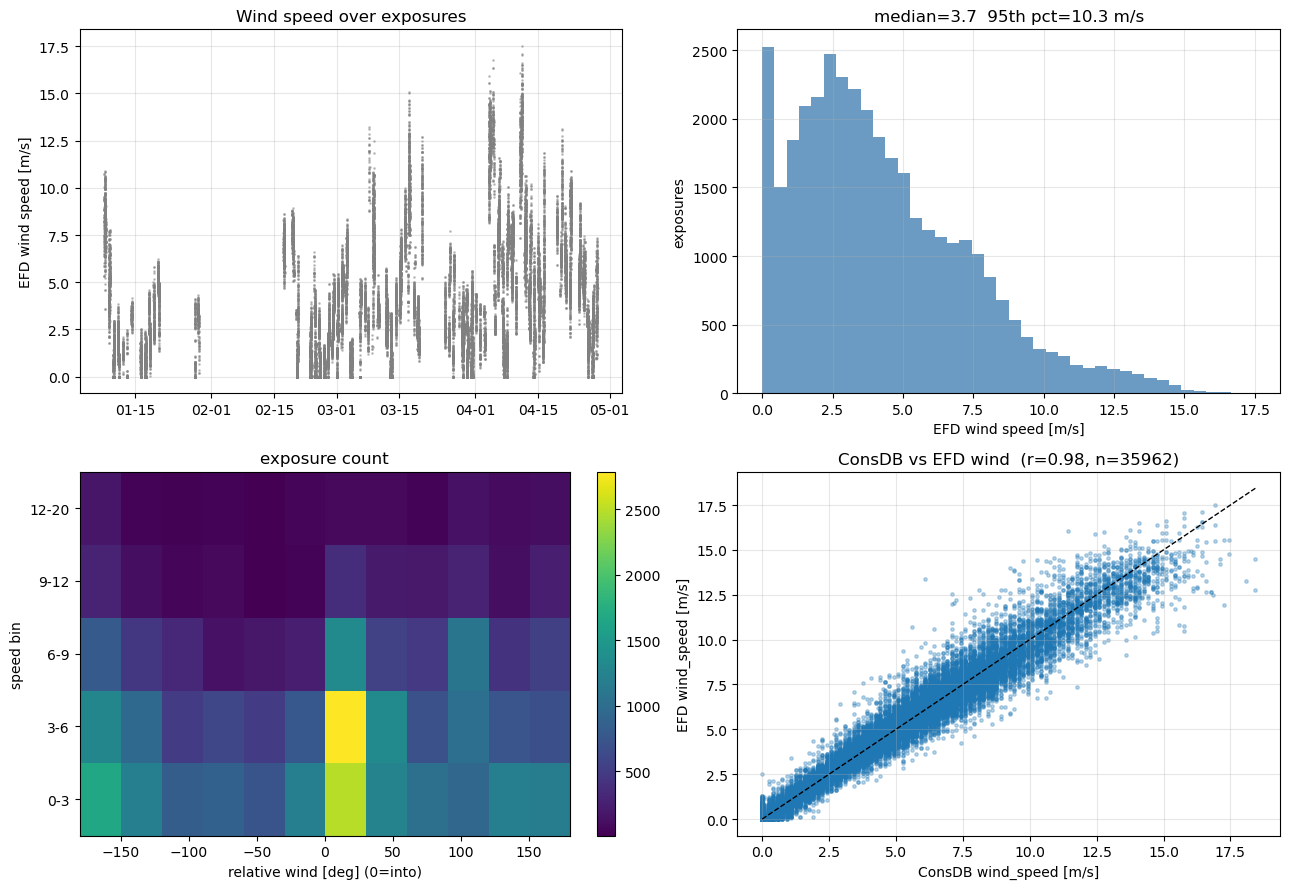

into-wind exposures: 12069   away-wind: 9979


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (1) wind speed time series with exposures overlaid
ax = axes[0, 0]
ax.plot(df.index, df["efd_wind_speed"], ".", ms=2, alpha=0.4, color="gray")
ax.set_ylabel("EFD wind speed [m/s]"); ax.set_title("Wind speed over exposures")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d")); ax.grid(alpha=0.3)

# (2) wind speed histogram
ax = axes[0, 1]
ax.hist(df["efd_wind_speed"].dropna(), bins=40, color="steelblue", alpha=0.8)
ax.set_xlabel("EFD wind speed [m/s]"); ax.set_ylabel("exposures")
ax.set_title(f"median={df['efd_wind_speed'].median():.1f}  "
             f"95th pct={df['efd_wind_speed'].quantile(0.95):.1f} m/s"); ax.grid(alpha=0.3)

# (3) exposure count heatmap: speed bin × rel-wind bin
ax = axes[1, 0]
sp_edges = np.array([0, 3, 6, 9, 12, 20])
rw_edges = np.arange(-180, 181, 30)
H, _, _ = np.histogram2d(df["efd_wind_speed"].fillna(-1), df["relative_wind"].fillna(-999),
                         bins=[sp_edges, rw_edges])
im = ax.imshow(H, aspect="auto", origin="lower", cmap="viridis",
               extent=[rw_edges[0], rw_edges[-1], 0, len(sp_edges)-1])
ax.set_xlabel("relative wind [deg] (0=into)"); ax.set_ylabel("speed bin")
ax.set_yticks(np.arange(len(sp_edges)-1)+0.5)
ax.set_yticklabels([f"{sp_edges[i]}-{sp_edges[i+1]}" for i in range(len(sp_edges)-1)])
ax.set_title("exposure count"); plt.colorbar(im, ax=ax, fraction=0.046)

# (4) ConsDB vs EFD wind cross-check
ax = axes[1, 1]
m = df["wind_speed"].notna() & df["efd_wind_speed"].notna()
ax.scatter(df.loc[m, "wind_speed"], df.loc[m, "efd_wind_speed"], s=6, alpha=0.3)
lim = [0, np.nanmax([df["wind_speed"].max(), df["efd_wind_speed"].max()])]
ax.plot(lim, lim, "k--", lw=1)
if m.sum() > 2:
    r = np.corrcoef(df.loc[m, "wind_speed"], df.loc[m, "efd_wind_speed"])[0, 1]
    ax.set_title(f"ConsDB vs EFD wind  (r={r:.2f}, n={m.sum()})")
ax.set_xlabel("ConsDB wind_speed [m/s]"); ax.set_ylabel("EFD wind_speed [m/s]"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"into-wind exposures: {df['into_wind'].sum()}   away-wind: {df['away_wind'].sum()}")

Wind-speed coverage during science observing:
  median=3.7  90th=8.5  95th=10.3  99th=13.5  max=17.5 m/s
  fraction >8 m/s: 12.6%   >12 m/s: 2.5%

Avoidance test  Spearman(wind_speed, |relative_wind|) = +0.04 (p=2.4e-13)
  (+ → point more AWAY from wind as it rises = active avoidance)

Max wind actually reached, into vs away:
  into (|Δ|<45°)   n=12069  median=3.5  95th=9.4  max=15.1 m/s
  away (|Δ|>135°)  n= 9979  median=3.8  95th=10.9  max=17.5 m/s


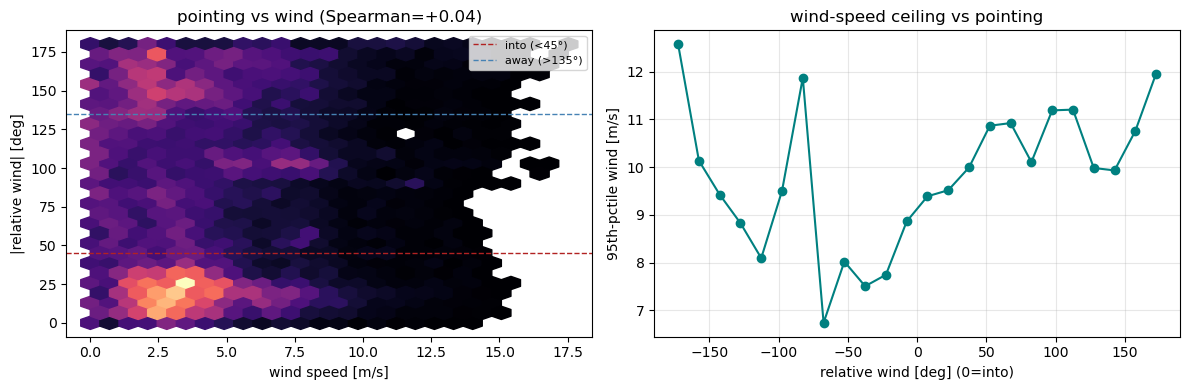

In [26]:
# ── Observing selection-bias diagnostic ─────────────────────────────────────
# Do operators avoid high wind, and point away from it when gusty? If so, the
# into-wind / high-wind regime is self-censored out of the science sample.
_m = df["efd_wind_speed"].notna() & df["abs_relative_wind"].notna()
_rho, _p = spstats.spearmanr(df.loc[_m, "efd_wind_speed"], df.loc[_m, "abs_relative_wind"])
ws = df["efd_wind_speed"]
print("Wind-speed coverage during science observing:")
print(f"  median={ws.median():.1f}  90th={ws.quantile(.9):.1f}  "
      f"95th={ws.quantile(.95):.1f}  99th={ws.quantile(.99):.1f}  max={ws.max():.1f} m/s")
print(f"  fraction >8 m/s: {(ws>8).mean()*100:.1f}%   >12 m/s: {(ws>12).mean()*100:.1f}%")
print(f"\nAvoidance test  Spearman(wind_speed, |relative_wind|) = {_rho:+.2f} (p={_p:.1e})")
print("  (+ → point more AWAY from wind as it rises = active avoidance)")
print("\nMax wind actually reached, into vs away:")
for _lab, _mask in [("into (|Δ|<45°)", df["into_wind"].fillna(False)),
                    ("away (|Δ|>135°)", df["away_wind"].fillna(False))]:
    _s = df.loc[_mask, "efd_wind_speed"]
    if _s.notna().any():
        print(f"  {_lab:16s} n={int(_mask.sum()):5d}  median={_s.median():.1f}  "
              f"95th={_s.quantile(.95):.1f}  max={_s.max():.1f} m/s")

# visualize: |relative_wind| vs wind speed (are high-wind frames pushed to |Δ|→180?)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hexbin(df.loc[_m, "efd_wind_speed"], df.loc[_m, "abs_relative_wind"],
             gridsize=25, cmap="magma", mincnt=1)
ax[0].axhline(INTO_WIND_MAX, color="firebrick", ls="--", lw=1, label=f"into (<{INTO_WIND_MAX:g}°)")
ax[0].axhline(AWAY_WIND_MIN, color="steelblue", ls="--", lw=1, label=f"away (>{AWAY_WIND_MIN:g}°)")
ax[0].set_xlabel("wind speed [m/s]"); ax[0].set_ylabel("|relative wind| [deg]")
ax[0].set_title(f"pointing vs wind (Spearman={_rho:+.2f})"); ax[0].legend(fontsize=8)
# max wind reached per relative-wind bin — shows the into-wind coverage ceiling
c, mx = [], []
for b in range(len(rel_wind_bins)-1):
    seg = df[(df["relative_wind"] >= rel_wind_bins[b]) & (df["relative_wind"] < rel_wind_bins[b+1])]
    c.append(0.5*(rel_wind_bins[b]+rel_wind_bins[b+1]))
    mx.append(seg["efd_wind_speed"].quantile(.95) if len(seg) > 5 else np.nan)
ax[1].plot(c, mx, "o-", color="teal")
ax[1].set_xlabel("relative wind [deg] (0=into)"); ax[1].set_ylabel("95th-pctile wind [m/s]")
ax[1].set_title("wind-speed ceiling vs pointing"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §11 — Measured aerodynamic loading: force & moment vs wind

**Primary force anchor: the M1M3 balance MOMENT** (`appliedBalanceForces` mx,my). The
force-balance loop actively drives the hardpoint loads toward zero, carrying the mirror on
the static support; what the loop *applies* is its response to disturbances (wind, thermal),
so the balance moment is the physical wind-load signal. This also gives the moment about the
mirror axes **directly** — no lever-arm assumption needed. (The raw hardpoint forces are the
loop *error residual* — ≈0 in steady state and dominated by slew-settle transients — so they
are retained only as a diagnostic, not the anchor.)

The aerodynamic prediction is that the wind moment scales with dynamic pressure `q ∝ V²`, so
we plot the wind moment against `V²` and look for linearity. The moment responds to the *net*
disturbance (elevation-dependent gravity residual + thermal + wind), so we isolate the wind
term by subtracting a per-elevation calm-wind baseline (median at V < 2 m/s in the same
elevation stratum); the residual is `wind_moment`.

Two data-quality controls (both verified to matter): the per-exposure statistics **skip the
first `SETTLE_SKIP_S` = 5 s** of each exposure (slew-settle transient — dynamic RMS ~halves
when excluded) and are computed at the **native ~50 Hz** rate (no 1 s pre-averaging, so the
dynamic content is preserved).

force anchor = bal_moment_mag (wind moment, per-elevation-baseline-subtracted, N·m)


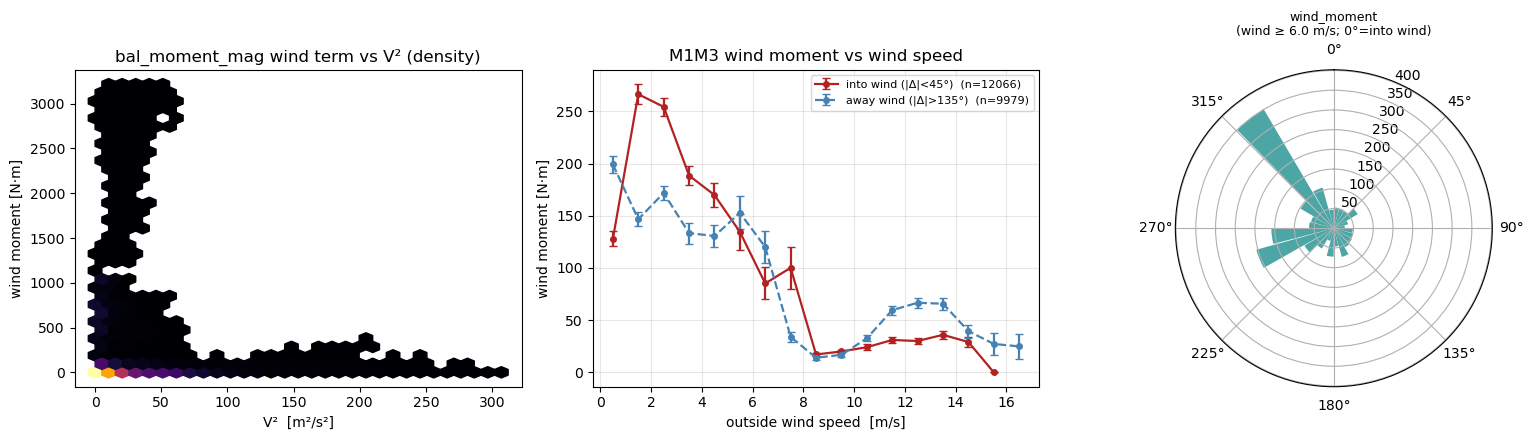

(diagnostic) corr(wind_moment, HP-excursion residual) = -0.00 — HP forces are the loop error, not the load


In [10]:
# PRIMARY force anchor: M1M3 balance MOMENT (the force-balance loop's disturbance
# response). Isolate the wind-driven part via a per-elevation calm-wind baseline
# (gravity/elevation term removed), leaving the wind moment.
FORCE_METRIC = "bal_moment_mag" if "bal_moment_mag" in df else "hp_force_excursion"
if FORCE_METRIC in df:
    df["_el_bin"] = pd.cut(df["mount_el_actual"].fillna(df["altitude"]),
                           bins=np.arange(0, 91, 15))
    low_wind = df[df["efd_wind_speed"] < 2.0]
    base = low_wind.groupby("_el_bin", observed=True)[FORCE_METRIC].median()
    df["wind_moment"] = (df[FORCE_METRIC] - df["_el_bin"].map(base)).clip(lower=0)
    HAVE_FORCE = df["wind_moment"].notna().sum() > 10
    _unit = "N·m" if FORCE_METRIC == "bal_moment_mag" else "N"
else:
    HAVE_FORCE = False
    print("⚠ no balance-moment / hardpoint force data — anchor (a) unavailable")

if HAVE_FORCE:
    print(f"force anchor = {FORCE_METRIC} (wind moment, per-elevation-baseline-subtracted, {_unit})")
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    # (1) wind moment vs V^2 hexbin — aero prediction is linear in V²
    ax = axes[0]
    m = df["efd_wind_speed"].notna() & df["wind_moment"].notna()
    ax.hexbin(df.loc[m, "efd_wind_speed"]**2, df.loc[m, "wind_moment"],
              gridsize=30, cmap="inferno", mincnt=1)
    ax.set_xlabel("V²  [m²/s²]"); ax.set_ylabel(f"wind moment [{_unit}]")
    ax.set_title(f"{FORCE_METRIC} wind term vs V² (density)")
    # (2) two-sided curve
    two_sided_curve(axes[1], df, "wind_moment", ylabel=f"wind moment [{_unit}]",
                    title="M1M3 wind moment vs wind speed")
    # (3) polar
    fig.delaxes(axes[2])
    axes[2] = fig.add_subplot(1, 3, 3, projection="polar")
    polar_by_relwind(axes[2], df, "wind_moment", speed_min=6.0)
    plt.tight_layout(); plt.show()
    # diagnostic: HP excursion (loop error residual) for comparison — should be small/noisy
    if "hp_force_excursion" in df:
        _r = df[["wind_moment","hp_force_excursion"]].corr().iloc[0,1]
        print(f"(diagnostic) corr(wind_moment, HP-excursion residual) = {_r:.2f} "
              "— HP forces are the loop error, not the load")

## §12 — Mirror bulk motion vs wind  *(anchor c)*

How far the mirror physically moves under wind: M1M3 piston (`zPosition`) and tip/tilt
(`x/yRotation`), plus M2. We also cross-check IMS motion against hardpoint force excursion
— both should track the same aerodynamic load.

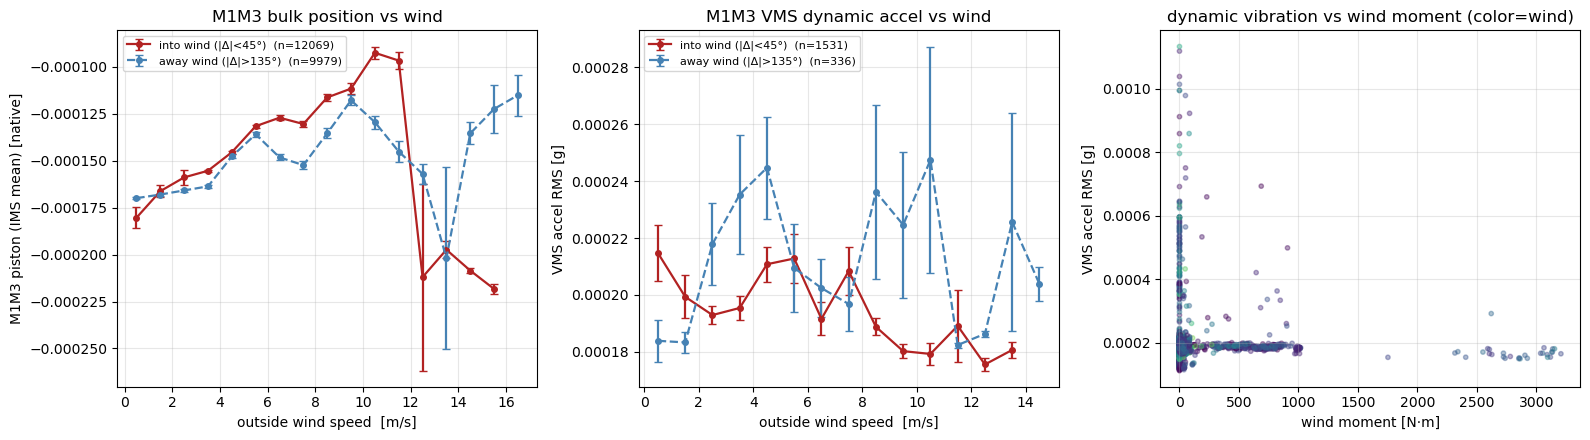

In [28]:
# Bulk static position from IMS mean; DYNAMIC motion from M1M3 VMS accelerometers
# (the IMS in-exposure std is at the sensor floor, so VMS is the dynamic anchor c).
HAVE_IMS = "m1m3_piston_um" in df and df["m1m3_piston_um"].notna().any()
HAVE_VMS_MOTION = "vms_accel_rms" in df and df["vms_accel_rms"].notna().sum() > 10

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
# (1) IMS bulk static position (piston) vs wind — quasi-static deflection
if HAVE_IMS:
    two_sided_curve(axes[0], df, "m1m3_piston_um",
                    ylabel="M1M3 piston (IMS mean) [native]", title="M1M3 bulk position vs wind")
else:
    axes[0].axis("off")
# (2) VMS broadband accel RMS vs wind — DYNAMIC anchor (c)
if HAVE_VMS_MOTION:
    two_sided_curve(axes[1], df, "vms_accel_rms", ylabel="VMS accel RMS [g]",
                    title="M1M3 VMS dynamic accel vs wind")
else:
    axes[1].axis("off")
    print("⚠ no VMS data joined — run build_vms.py; dynamic anchor (c) unavailable")
# (3) VMS dynamic accel vs measured wind moment — mechanical consistency
ax = axes[2]
if HAVE_VMS_MOTION and HAVE_FORCE:
    m = df["wind_moment"].notna() & df["vms_accel_rms"].notna()
    ax.scatter(df.loc[m, "wind_moment"], df.loc[m, "vms_accel_rms"],
               s=10, alpha=0.4, c=df.loc[m, "efd_wind_speed"], cmap="viridis")
    ax.set_xlabel("wind moment [N·m]"); ax.set_ylabel("VMS accel RMS [g]")
    ax.set_title("dynamic vibration vs wind moment (color=wind)"); ax.grid(alpha=0.3)
else:
    ax.axis("off")
plt.tight_layout(); plt.show()

## §13 — Mount jitter & image degradation vs wind  *(anchor b)*

ConsDB `mount_jitter_rms` and `mount_motion_image_degradation` (total + az/el/rot), which
quantify how much the bulk telescope tracking error blurs the image. We split into/away and
decompose by axis — pointing into the wind should load the elevation/pitch axis differently
than crosswind. Elevation is a known covariate (handled in §16).

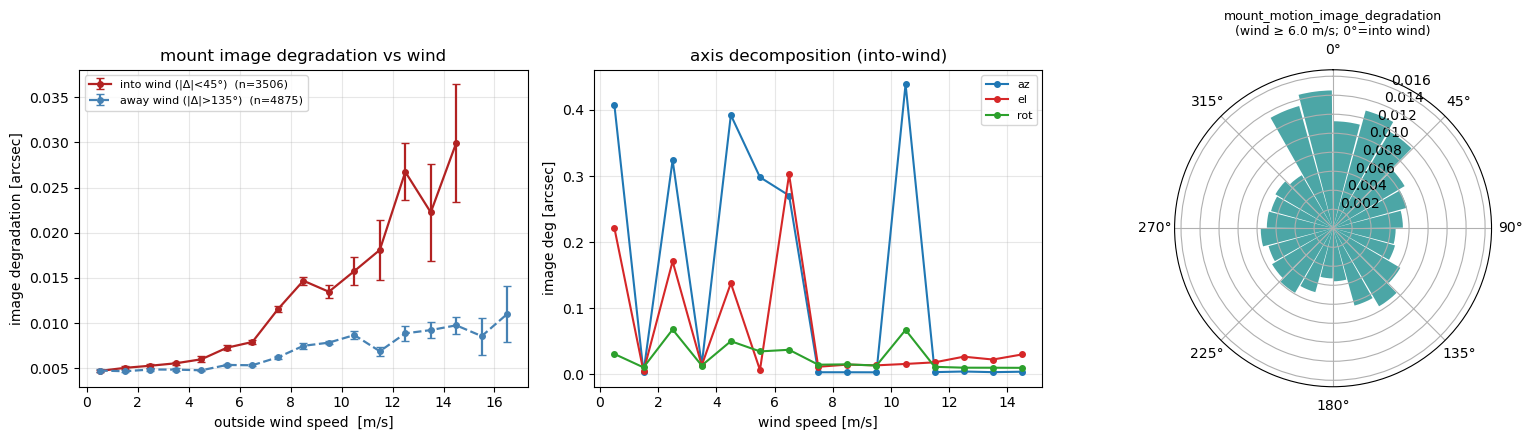

In [11]:
jit_total = "mount_motion_image_degradation"
HAVE_JIT = jit_total in df and df[jit_total].notna().sum() > 10
if not HAVE_JIT:
    print("⚠ no mount-motion data in this window — anchor (b) unavailable")
else:
    # clip non-physical values
    for c in [jit_total, "mount_jitter_rms"]:
        if c in df:
            df.loc[(df[c] < MOUNT_JITTER_MIN) | (df[c] > MOUNT_JITTER_MAX), c] = np.nan
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    two_sided_curve(axes[0], df, jit_total, ylabel="image degradation [arcsec]",
                    title="mount image degradation vs wind")
    # az vs el decomposition (binned means vs speed, into-wind only)
    ax = axes[1]
    sub = df[df["into_wind"].fillna(False)]
    for axis_col, color in [("mount_motion_image_degradation_az", "tab:blue"),
                            ("mount_motion_image_degradation_el", "tab:red"),
                            ("mount_motion_image_degradation_rot", "tab:green")]:
        if axis_col in df:
            c, mean, std, sem, cnt = binned_stats(sub["efd_wind_speed"], sub[axis_col],
                                                  speed_fit_bins)
            k = cnt >= 3
            ax.plot(c[k], mean[k], "o-", color=color, ms=4,
                    label=axis_col.split("_")[-1])
    ax.set_xlabel("wind speed [m/s]"); ax.set_ylabel("image deg [arcsec]")
    ax.set_title("axis decomposition (into-wind)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    fig.delaxes(axes[2])
    axes[2] = fig.add_subplot(1, 3, 3, projection="polar")
    polar_by_relwind(axes[2], df, jit_total, speed_min=6.0)
    plt.tight_layout(); plt.show()

## §13b — Wind-induced oscillations (M1M3 VMS dynamic / spectral response)

The IMS in-exposure dynamic RMS is at the sensor floor, so the oscillation analysis uses
the **M1M3 Vibration Monitoring System** (`lsst.sal.MTVMS.data`, salIndex=1): 3
accelerometers × 3 axes at ~240 Hz per sensor, sampled over a wind-stratified set of
exposures (§ VMS join) with per-exposure Welch PSDs computed on the settled part of each
exposure (`build_vms.py`). We show:

1. the **wind-speed-stacked median acceleration PSD** — a spectral peak whose amplitude
   grows with wind speed is a wind-driven **structural resonance**;
2. **band-limited accel RMS** (0–1 / 1–5 / 5–20 / 20–100 Hz) vs wind speed;
3. the **dominant peak frequency** distribution, low vs high wind.

Broadband buffeting grows smoothly with V²; a narrowband resonance sits at a fixed
frequency with wind-dependent amplitude.

In [30]:
# VMS PSD products are precomputed by build_vms.py; just confirm availability here.
_vms_stk = CACHE_DIR / f"wind_loading_vmsstack_{day_obs_start}_{day_obs_end}.parquet"
HAVE_VMS_PSD = ("vms_accel_rms" in df and df["vms_accel_rms"].notna().sum() > 10)
HAVE_VMS_STACK = _vms_stk.exists()
print(f"VMS per-exposure spectral: {'available' if HAVE_VMS_PSD else 'NONE'}"
      + (f" ({int(df['vms_accel_rms'].notna().sum())} exp)" if HAVE_VMS_PSD else ""))
print(f"VMS stacked PSD: {'available' if HAVE_VMS_STACK else 'NONE'}")

VMS per-exposure spectral: available (2157 exp)
VMS stacked PSD: available


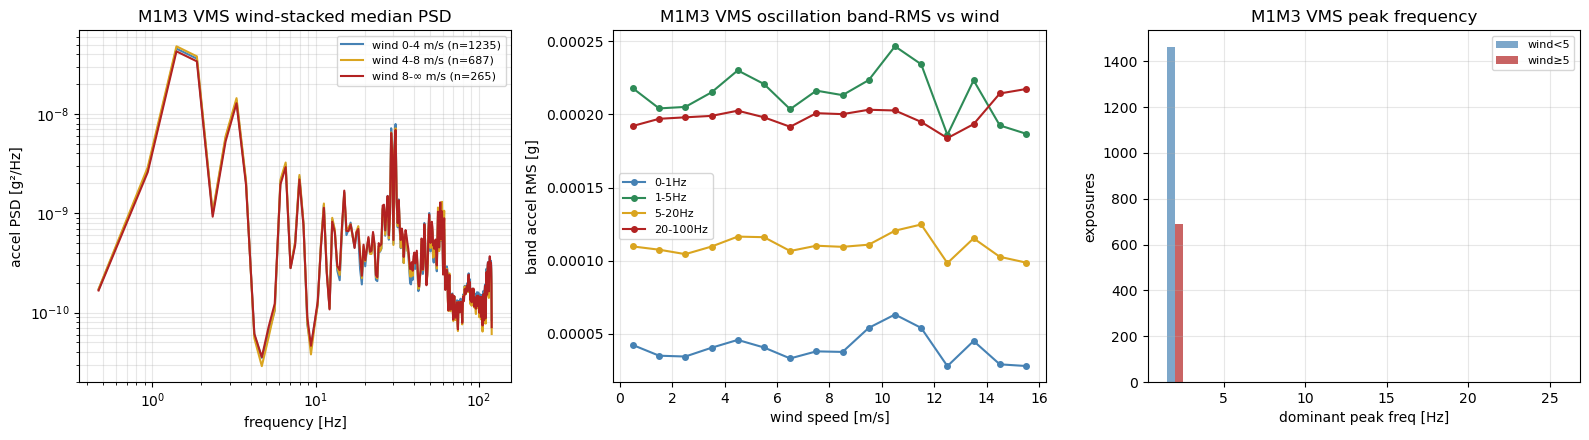

In [31]:
if HAVE_VMS_PSD or HAVE_VMS_STACK:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    # (1) wind-stacked median acceleration PSD — resonance hunt
    ax = axes[0]
    if HAVE_VMS_STACK:
        st = pd.read_parquet(_vms_stk)
        for (lo_v, hi_v), col in zip(sorted(set(zip(st["wind_lo"], st["wind_hi"]))),
                                     ["steelblue", "goldenrod", "firebrick"]):
            seg = st[(st["wind_lo"] == lo_v) & (st["wind_hi"] == hi_v)].sort_values("freq_hz")
            if len(seg) < 3:
                continue
            n = int(seg["n_exp"].iloc[0])
            lab = f"wind {lo_v}-{'∞' if hi_v>=90 else hi_v} m/s (n={n})"
            ax.loglog(seg["freq_hz"][1:], seg["psd_median"][1:], color=col, label=lab)
        ax.set_xlabel("frequency [Hz]"); ax.set_ylabel("accel PSD [g²/Hz]")
        ax.set_title("M1M3 VMS wind-stacked median PSD"); ax.legend(fontsize=8)
        ax.grid(alpha=0.3, which="both")
    else:
        ax.axis("off")
    # (2) band-limited accel RMS vs wind speed
    ax = axes[1]
    if HAVE_VMS_PSD:
        band_cols = [c for c in df.columns if c.startswith("vms_accel_rms_")]
        cols = ["steelblue", "seagreen", "goldenrod", "firebrick"]
        for bc, col in zip(band_cols, cols):
            c, mean, std, sem, cnt = binned_stats(df["efd_wind_speed"], df[bc], speed_fit_bins)
            k = cnt >= 3
            ax.plot(c[k], mean[k], "o-", color=col, ms=4,
                    label=bc.replace("vms_accel_rms_", "").replace("_", "-"))
        ax.set_xlabel("wind speed [m/s]"); ax.set_ylabel("band accel RMS [g]")
        ax.set_title("M1M3 VMS oscillation band-RMS vs wind")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
    else:
        ax.axis("off")
    # (3) dominant peak frequency, low vs high wind
    ax = axes[2]
    if HAVE_VMS_PSD and "vms_peak_hz" in df:
        lo = df[df["efd_wind_speed"] < 5]["vms_peak_hz"].dropna()
        hi = df[df["efd_wind_speed"] >= 5]["vms_peak_hz"].dropna()
        ax.hist([lo, hi], bins=20, label=["wind<5", "wind≥5"],
                color=["steelblue", "firebrick"], alpha=0.7)
        ax.set_xlabel("dominant peak freq [Hz]"); ax.set_ylabel("exposures")
        ax.set_title("M1M3 VMS peak frequency"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    else:
        ax.axis("off")
    plt.tight_layout(); plt.show()
else:
    print("VMS spectral section skipped — run build_vms.py to populate the VMS caches.")

## §14 — PSF / AOS degradation vs wind  *(anchor d)*

End-to-end delivered image quality: PSF FWHM (from `psf_sigma_median`), `aos_fwhm`,
`donut_blur_fwhm`, and — as a directional *compass* — image quality binned by relative
wind direction. The compass prefers the wind-driven Zernike response (z4 focus, z5/z6
astig, z7/z8 coma), but ConsDB Zernikes are **all-null in this window**, so it falls back
to the best available IQ metric (PSF FWHM) to answer: does delivered IQ depend on wind
*direction*? **Big confound:** the same wind drives outside seeing, dome turbulence, and
thermal mixing — so this is the noisiest anchor. §16 separates the wind-mechanical component.

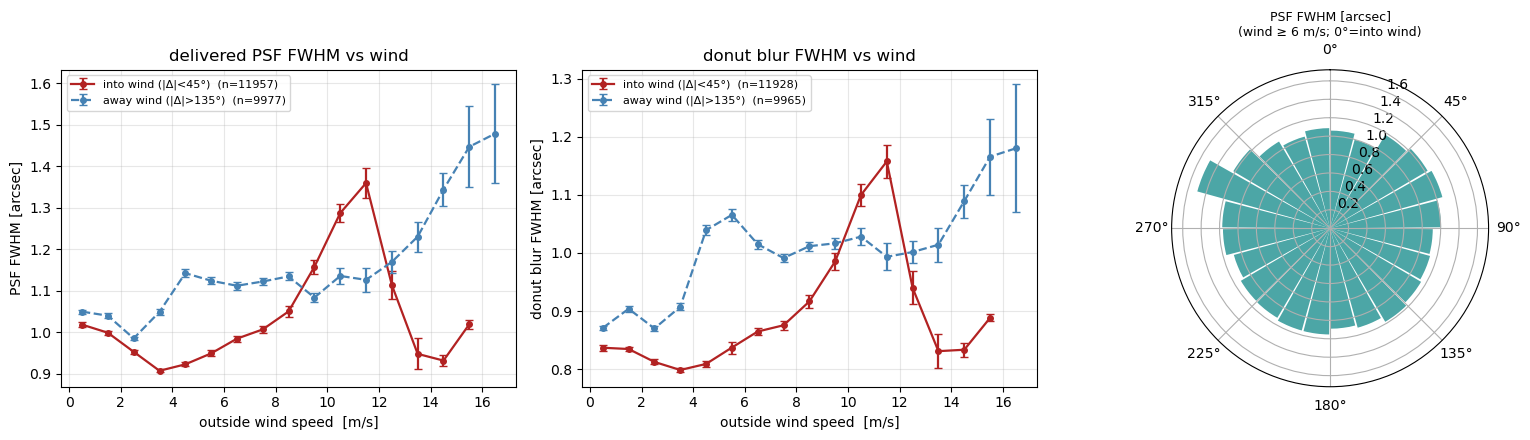

In [10]:
PIXSCALE = 0.2  # arcsec/pix (LSSTCam)
# Tracking-jitter budget for the bulk-motion anchors (mount_jitter_rms, guider RMS).
# This analysis isolates the WIND-driven contribution, so the anchor budget is the
# WIND-BUFFETING ALLOCATION (< 0.047"), NOT the total tracking-jitter design
# requirement (0.01"). The 0.01" requirement is the full error budget across all
# sources (servo, encoder, thermal, wind); wind gets its own larger sub-budget.
WIND_JITTER_ALLOCATION   = 0.047   # arcsec — wind-buffeting jitter allocation
TRACK_JITTER_REQUIREMENT = 0.01    # arcsec — total design requirement (shown for context)
TRACK_JITTER_LIMIT = WIND_JITTER_ALLOCATION   # anchor budget = wind allocation

# ConsDB numeric columns can arrive as Decimal/object — coerce to float
for _c in ["psf_sigma_median", "aos_fwhm", "donut_blur_fwhm",
           "z4", "z5", "z6", "z7", "z8",
           "guider_magnitude_rms_detrended", "mount_jitter_rms"]:
    if _c in df:
        df[_c] = pd.to_numeric(df[_c], errors="coerce")
if "psf_sigma_median" in df:
    df["psf_fwhm_asec"] = df["psf_sigma_median"] * 2.355 * PIXSCALE

# Guider magnitude RMS is reported in MILLI-arcsec (verified: median ~3.4 mas,
# p95 ~12 mas → same scale as mount_jitter_rms in arcsec, both crossing 0.01" at
# ~6% of exposures). Convert to arcsec so it shares the tracking-jitter limit.
if "guider_magnitude_rms_detrended" in df:
    df["guider_rms_asec"] = df["guider_magnitude_rms_detrended"] / 1000.0
HAVE_PSF = "psf_fwhm_asec" in df and df["psf_fwhm_asec"].notna().sum() > 10

if not HAVE_PSF:
    print("⚠ no PSF data in this window — anchor (d) available only via aos_fwhm")
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
if HAVE_PSF:
    two_sided_curve(axes[0], df, "psf_fwhm_asec", ylabel="PSF FWHM [arcsec]",
                    title="delivered PSF FWHM vs wind")
# donut blur FWHM (out-of-focus blur; independent IQ anchor alongside PSF FWHM)
if "donut_blur_fwhm" in df and df["donut_blur_fwhm"].notna().sum() > 10:
    two_sided_curve(axes[1], df, "donut_blur_fwhm", ylabel="donut blur FWHM [arcsec]",
                    title="donut blur FWHM vs wind")
elif "aos_fwhm" in df and df["aos_fwhm"].notna().sum() > 5:
    two_sided_curve(axes[1], df, "aos_fwhm", ylabel="AOS FWHM [arcsec]",
                    title="AOS FWHM vs wind")
# Compass: does delivered image quality depend on wind DIRECTION?
# Preferred metric is Zernike (z4-z8 RMS), but ConsDB Zernikes are all-null in
# this window, so fall back to the best available IQ anchor with real data.
ax = axes[2]
zc = [c for c in ["z4","z5","z6","z7","z8"] if c in df]
# min_count=1 so all-null rows stay NaN (plain .sum skips NaN and returns
# 0.0 for an all-null row, which would masquerade as real data).
df["_zern_rms"] = (np.sqrt((df[zc]**2).sum(axis=1, min_count=1)) if zc else np.nan)
_HAVE_ZERN = zc and df["_zern_rms"].notna().sum() > 10
if _HAVE_ZERN:
    _compass_metric, _compass_label = "_zern_rms", "z4-z8 RMS"
elif "psf_fwhm_asec" in df and df["psf_fwhm_asec"].notna().sum() > 10:
    _compass_metric, _compass_label = "psf_fwhm_asec", "PSF FWHM [arcsec]"
elif "donut_blur_fwhm" in df and df["donut_blur_fwhm"].notna().sum() > 10:
    _compass_metric, _compass_label = "donut_blur_fwhm", "donut blur FWHM [arcsec]"
else:
    _compass_metric = None
if _compass_metric is not None:
    # Replace the cartesian axes[2] with a polar one (delete first so the
    # original box/grid doesn't linger behind the compass).
    fig.delaxes(axes[2])
    axes[2] = fig.add_subplot(1, 3, 3, projection="polar")
    polar_by_relwind(axes[2], df, _compass_metric, speed_min=6.0)
    axes[2].set_title(f"{_compass_label}\n(wind \u2265 6 m/s; 0\u00b0=into wind)", fontsize=9)
else:
    ax.axis("off")
    print("\u26a0 no directional IQ metric available for compass panel")
plt.tight_layout(); plt.show()

## §14b — Guider RMS motion vs wind  *(anchor e — most direct in-exposure IQ measure)*

`guider_magnitude_rms_detrended` integrates the *actual* image motion during the exposure.
Unlike PSF/AOS, it is largely free of the atmospheric-seeing confound, making it the
cleanest mechanical-IQ anchor. We split into/away, decompose by axis (altitude / azimuth /
field-rotation), and cross-check against `mount_jitter_rms` (§13) and the §13b oscillation
band-RMS — do wind-driven resonances show up in the guider?

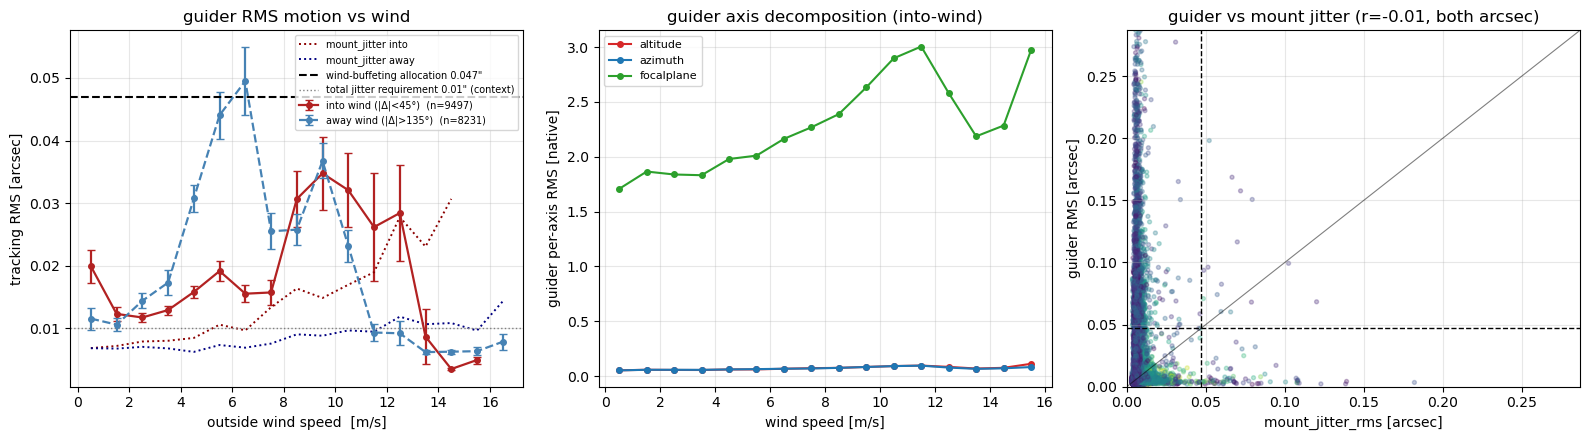

guider RMS: 7.6% of exposures exceed the 0.047" wind-buffeting allocation (18% exceed the 0.01" total requirement)
mount jitter: 0.3% exceed the 0.047" wind allocation


In [33]:
g_primary = "guider_rms_asec" if "guider_rms_asec" in df else "guider_magnitude_rms_detrended"
HAVE_GUIDER = g_primary in df and df[g_primary].notna().sum() > 10
if not HAVE_GUIDER:
    print("⚠ no guider RMS data in this window — anchor (e) unavailable")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    # (1) guider RMS (arcsec) AND mount jitter (arcsec) vs wind, with 0.01" limit
    out = two_sided_curve(axes[0], df, g_primary, ylabel="tracking RMS [arcsec]",
                          title="guider RMS motion vs wind")
    if "mount_jitter_rms" in df:
        for case, mask, col, ls in [("into", df["into_wind"].fillna(False), "darkred", ":"),
                                    ("away", df["away_wind"].fillna(False), "navy", ":")]:
            sub = df[mask]
            c, mean, std, sem, cnt = binned_stats(sub["efd_wind_speed"],
                                                  sub["mount_jitter_rms"], speed_fit_bins)
            k = cnt >= 3
            axes[0].plot(c[k], mean[k], ls, color=col, lw=1.4,
                         label=f"mount_jitter {case}")
    axes[0].axhline(TRACK_JITTER_LIMIT, color="k", ls="--", lw=1.5,
                    label=f"wind-buffeting allocation {TRACK_JITTER_LIMIT}\"")
    axes[0].axhline(TRACK_JITTER_REQUIREMENT, color="gray", ls=":", lw=1,
                    label=f"total jitter requirement {TRACK_JITTER_REQUIREMENT}\" (context)")
    axes[0].legend(fontsize=7)
    # (2) axis decomposition (into-wind) — native per-axis guider RMS
    ax = axes[1]
    sub = df[df["into_wind"].fillna(False)]
    for gc, color in [("guider_altitude_rms_detrended", "tab:red"),
                      ("guider_azimuth_rms_detrended", "tab:blue"),
                      ("guider_focalplane_theta_rms_detrended", "tab:green")]:
        if gc in df:
            c, mean, std, sem, cnt = binned_stats(sub["efd_wind_speed"],
                                                  pd.to_numeric(sub[gc], errors="coerce"),
                                                  speed_fit_bins)
            k = cnt >= 3
            ax.plot(c[k], mean[k], "o-", color=color, ms=4, label=gc.split("_")[1])
    ax.set_xlabel("wind speed [m/s]"); ax.set_ylabel("guider per-axis RMS [native]")
    ax.set_title("guider axis decomposition (into-wind)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    # (3) guider RMS vs mount jitter (both arcsec) with 1:1 and limit box
    ax = axes[2]
    if "mount_jitter_rms" in df:
        m = df[g_primary].notna() & df["mount_jitter_rms"].notna()
        ax.scatter(df.loc[m, "mount_jitter_rms"], df.loc[m, g_primary],
                   s=8, alpha=0.3, c=df.loc[m, "efd_wind_speed"], cmap="viridis")
        lim = max(df.loc[m, "mount_jitter_rms"].quantile(.99),
                  df.loc[m, g_primary].quantile(.99), TRACK_JITTER_LIMIT*1.5)
        ax.plot([0, lim], [0, lim], "k-", lw=0.8, alpha=0.5)
        ax.axhline(TRACK_JITTER_LIMIT, color="k", ls="--", lw=1)
        ax.axvline(TRACK_JITTER_LIMIT, color="k", ls="--", lw=1)
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.set_xlabel("mount_jitter_rms [arcsec]"); ax.set_ylabel("guider RMS [arcsec]")
        if m.sum() > 2:
            r = np.corrcoef(df.loc[m, "mount_jitter_rms"], df.loc[m, g_primary])[0, 1]
            ax.set_title(f"guider vs mount jitter (r={r:.2f}, both arcsec)")
        ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f"guider RMS: {(df[g_primary]>TRACK_JITTER_LIMIT).mean()*100:.1f}% of exposures "
          f"exceed the {TRACK_JITTER_LIMIT}\" wind-buffeting allocation "
          f"({(df[g_primary]>TRACK_JITTER_REQUIREMENT).mean()*100:.0f}% exceed the {TRACK_JITTER_REQUIREMENT}\" total requirement)")
    if "mount_jitter_rms" in df:
        print(f"mount jitter: {(df['mount_jitter_rms']>TRACK_JITTER_LIMIT).mean()*100:.1f}% "
              f"exceed the {TRACK_JITTER_LIMIT}\" wind allocation")

## §15 — Dust ingression vs wind

Particulate influx through the open shutter/louvers. We attach `particle_total_count`
(sum of `numberConcentration0..4`, per-index median over each exposure window) to the
exposures and study it vs wind speed and relative direction — pointing *into* the wind
should ingest more through the open aperture. Louver azimuths (`../data/louver_map.csv`)
give context on which openings face the wind. This feeds a **separate contamination note**,
not the five IQ/mechanical anchors. Gracefully reports "no data" if the sensors are empty.

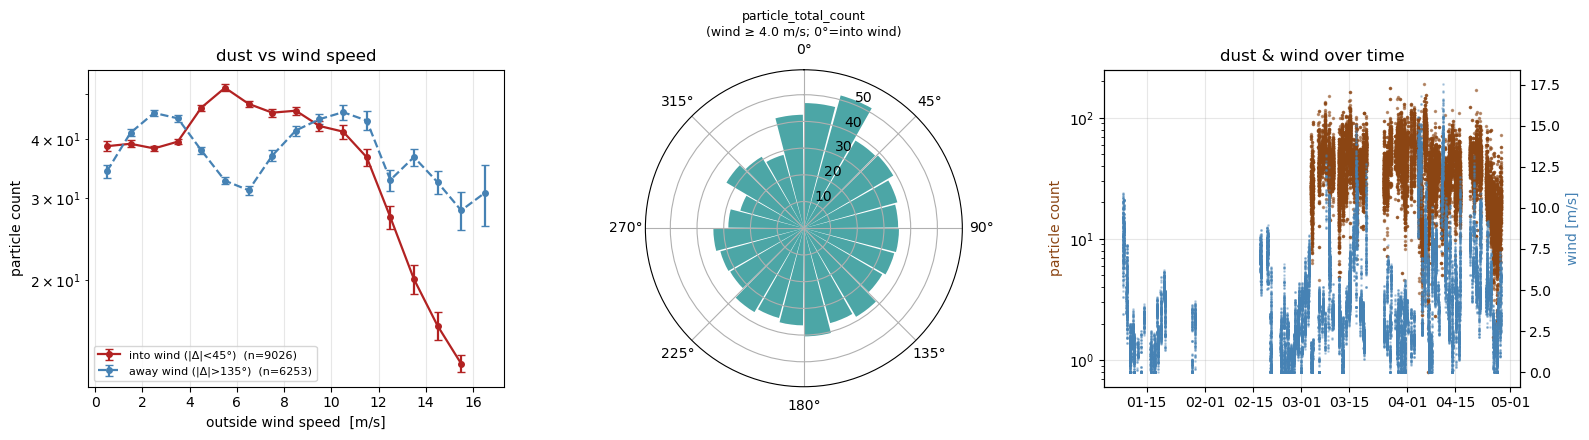


Ingression summary (23787 exposures with dust + wind):
  median particle count  into-wind (>4 m/s): 42
  median particle count  away-wind (>4 m/s): 33
  into/away ratio                          : 1.28  (into-wind ingests more — consistent with open-aperture influx)
  dust vs wind speed  Spearman rho=+0.00 (p=4.8e-01)
  high-wind(≥8)/low-wind(<4) median ratio  : 0.94


In [12]:
dust_summary = {"available": False}
HAVE_DUST = "particle_total_count" in df and df["particle_total_count"].notna().sum() > 10
if not HAVE_DUST:
    print("No dust/particle ingression data available for this window — section skipped.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    two_sided_curve(axes[0], df, "particle_total_count",
                    ylabel="particle count", title="dust vs wind speed", logy=True)
    fig.delaxes(axes[1])
    axes[1] = fig.add_subplot(1, 3, 2, projection="polar")
    polar_by_relwind(axes[1], df, "particle_total_count", speed_min=4.0)
    ax = axes[2]
    ax.plot(df.index, df["particle_total_count"], ".", ms=3, color="saddlebrown", alpha=0.5)
    ax.set_ylabel("particle count", color="saddlebrown"); ax.set_yscale("log")
    ax2 = ax.twinx(); ax2.plot(df.index, df["efd_wind_speed"], ".", ms=2, color="steelblue", alpha=0.3)
    ax2.set_ylabel("wind [m/s]", color="steelblue")
    ax.set_title("dust & wind over time")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d")); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    # ── Quantitative ingression summary (carried to §22) ────────────────────
    d = df[df["particle_total_count"].notna() & df["efd_wind_speed"].notna()]
    into = d[d["into_wind"].fillna(False) & (d["efd_wind_speed"] > 4)]["particle_total_count"]
    away = d[d["away_wind"].fillna(False) & (d["efd_wind_speed"] > 4)]["particle_total_count"]
    med_into, med_away = into.median(), away.median()
    ratio = med_into / med_away if med_away and np.isfinite(med_away) and med_away > 0 else np.nan
    # wind-speed dependence: Spearman correlation + low-vs-high-wind ratio
    rho, pval = spstats.spearmanr(d["efd_wind_speed"], d["particle_total_count"])
    lo = d[d["efd_wind_speed"] < 4]["particle_total_count"].median()
    hi = d[d["efd_wind_speed"] >= 8]["particle_total_count"].median()
    wind_ratio = hi / lo if lo and np.isfinite(lo) and lo > 0 else np.nan
    dust_summary = {
        "available": True,
        "n": int(len(d)),
        "median_into_gt4": med_into, "median_away_gt4": med_away,
        "into_away_ratio": ratio,
        "spearman_rho_vs_wind": rho, "spearman_p": pval,
        "median_lowwind_lt4": lo, "median_highwind_ge8": hi,
        "highwind_lowwind_ratio": wind_ratio,
    }
    print(f"\nIngression summary ({len(d)} exposures with dust + wind):")
    print(f"  median particle count  into-wind (>4 m/s): {med_into:.0f}")
    print(f"  median particle count  away-wind (>4 m/s): {med_away:.0f}")
    print(f"  into/away ratio                          : {ratio:.2f}"
          + ("  (into-wind ingests more — consistent with open-aperture influx)"
             if ratio == ratio and ratio > 1 else ""))
    print(f"  dust vs wind speed  Spearman rho={rho:+.2f} (p={pval:.1e})")
    print(f"  high-wind(≥8)/low-wind(<4) median ratio  : {wind_ratio:.2f}")

---
# Layer B — First-principles aerodynamic model

We first isolate the *wind-mechanical* signal from the wind-*seeing*/thermal confound
(§16), then build the aerodynamic model (§17) and validate it against the measured
telemetry (§18). The model is what lets us extrapolate the operational limits beyond the
observed wind-speed range in §20.

## §16 — Confound-controlled attribution

The same wind that mechanically loads the telescope also drives outside seeing, dome
turbulence, and thermal mixing. Before anchoring limits we regress each anchor metric on
`[V, V², elevation, dimm_seeing, inside_turb_speed, air_temp, humidity]` (standardized OLS)
and report the **partial dependence on wind at fixed confounds**. The mechanical anchors
(force, jitter, guider) should show a clean wind signal; PSF should show a weaker
wind-mechanical term once seeing is removed. The "wind-only" partial slope on `V²` is
carried into §20.

In [35]:
from numpy.linalg import lstsq

ANCHOR_METRICS = {
    "a_force":   "wind_moment",
    "b_jitter":  "mount_jitter_rms",          # tracking jitter [arcsec], 0.047" wind allocation
    "c_motion":  "vms_accel_rms",           # M1M3 VMS broadband accel [g] (was floor-limited IMS)
    "d_psf":     "psf_fwhm_asec",
    "d2_donut":  "donut_blur_fwhm",           # out-of-focus blur [arcsec]
    "e_guider":  "guider_rms_asec",           # guider image-motion RMS [arcsec], 0.047" wind allocation
}
CONFOUNDS = ["efd_wind_speed", "wind_sq", "elevation", "dimm_seeing",
             "inside_turb_speed", "air_temp", "humidity"]

df["wind_sq"]   = df["efd_wind_speed"]**2
df["elevation"] = df["mount_el_actual"].fillna(df["altitude"])

def standardized_ols(frame, ycol, xcols):
    d = frame[[ycol] + xcols].replace([np.inf, -np.inf], np.nan).dropna()
    if len(d) < max(20, 2*len(xcols)):
        return None
    X = d[xcols].to_numpy(float); y = d[ycol].to_numpy(float)
    Xm, Xs = X.mean(0), X.std(0); Xs[Xs == 0] = 1
    ym, ys = y.mean(), y.std() or 1
    Xz = (X - Xm)/Xs; yz = (y - ym)/ys
    A = np.column_stack([np.ones(len(Xz)), Xz])
    beta, *_ = lstsq(A, yz, rcond=None)
    yhat = A @ beta
    ss_res = ((yz - yhat)**2).sum(); ss_tot = ((yz - yz.mean())**2).sum()
    r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
    return {"coef": dict(zip(xcols, beta[1:])), "r2": r2, "n": len(d)}

attr = {}
print(f"{'anchor':10s} {'n':>5s} {'R²':>6s}  standardized coefficients (wind, V², elev, seeing, turb, T, RH)")
for key, metric in ANCHOR_METRICS.items():
    if metric not in df:
        print(f"{key:10s}  metric '{metric}' absent"); continue
    res = standardized_ols(df, metric, [c for c in CONFOUNDS if c in df])
    attr[key] = res
    if res:
        cs = res["coef"]
        print(f"{key:10s} {res['n']:5d} {res['r2']:6.2f}  "
              + "  ".join(f"{cs.get(c, np.nan):+.2f}" for c in
                          ["efd_wind_speed","wind_sq","elevation","dimm_seeing",
                           "inside_turb_speed","air_temp","humidity"]))
    else:
        print(f"{key:10s}  insufficient data")

anchor         n     R²  standardized coefficients (wind, V², elev, seeing, turb, T, RH)
a_force    12417   0.08  -0.39  +0.16  +0.16  -0.18  -0.04  -0.12  -0.04
b_jitter    4985   0.06  -0.04  +0.19  +0.11  -0.00  +0.12  +0.01  -0.00
c_motion     695   0.13  +0.04  -0.02  -0.31  -0.06  -0.06  -0.16  -0.12
d_psf      12364   0.54  +0.31  +0.02  -0.35  +0.54  -0.09  -0.13  -0.00
d2_donut   12350   0.37  +0.45  -0.23  -0.21  +0.48  -0.09  -0.21  -0.02
e_guider    9836   0.06  +0.37  -0.39  +0.05  +0.08  -0.06  -0.22  -0.10


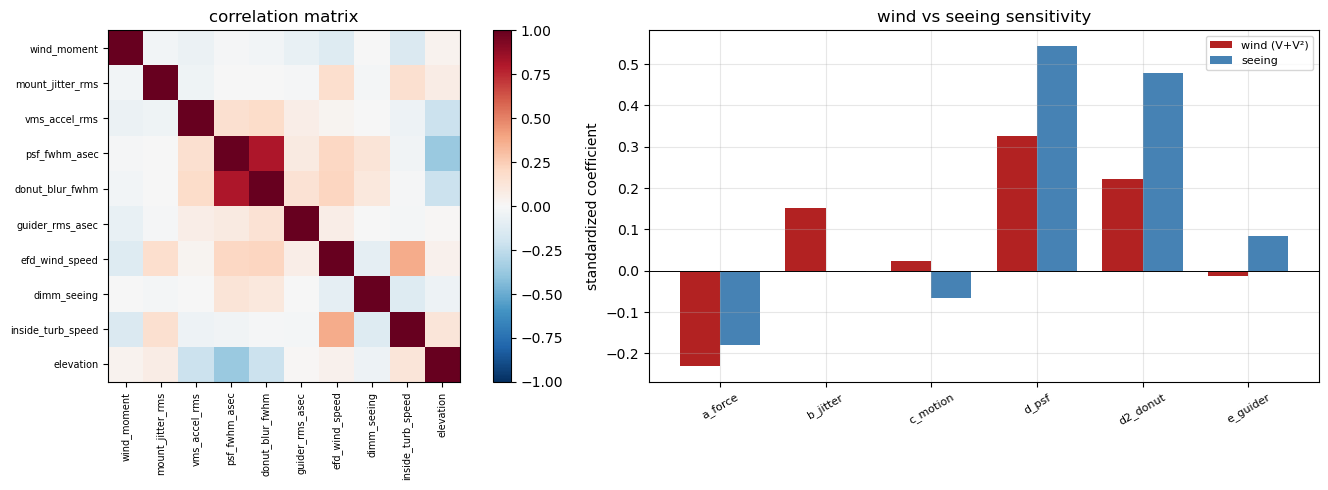

Mechanical anchors (force/jitter/guider) should be wind-dominated & seeing-insensitive;
PSF is expected to carry the largest seeing term.


In [36]:
# Correlation matrix of anchors + drivers + partial-dependence bars
avail_metrics = [m for m in ANCHOR_METRICS.values() if m in df]
cols = avail_metrics + [c for c in ["efd_wind_speed","dimm_seeing",
                                    "inside_turb_speed","elevation"] if c in df]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax = axes[0]
cm = df[cols].replace([np.inf,-np.inf], np.nan).corr()
im = ax.imshow(cm, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols, rotation=90, fontsize=7)
ax.set_yticks(range(len(cols))); ax.set_yticklabels(cols, fontsize=7)
ax.set_title("correlation matrix"); plt.colorbar(im, ax=ax, fraction=0.046)

# combined V + V² standardized wind sensitivity per anchor
ax = axes[1]
keys = [k for k in ANCHOR_METRICS if attr.get(k)]
wind_sens = [attr[k]["coef"].get("efd_wind_speed",0)+attr[k]["coef"].get("wind_sq",0)
             for k in keys]
see_sens  = [attr[k]["coef"].get("dimm_seeing",0) for k in keys]
x = np.arange(len(keys)); w = 0.38
ax.bar(x-w/2, wind_sens, w, label="wind (V+V²)", color="firebrick")
ax.bar(x+w/2, see_sens,  w, label="seeing", color="steelblue")
ax.set_xticks(x); ax.set_xticklabels(keys, rotation=30, fontsize=8)
ax.axhline(0, color="k", lw=0.7)
ax.set_ylabel("standardized coefficient"); ax.set_title("wind vs seeing sensitivity")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Mechanical anchors (force/jitter/guider) should be wind-dominated & seeing-insensitive;")
print("PSF is expected to carry the largest seeing term.")

## §16b — Wind → image-quality pathway & degraded-ops (20 m/s) degradation

The delivered image quality (PSF FWHM, donut blur) rises steeply with wind, yet §11–§13b
show it is **not** rigid-body mechanical buffeting (the M1M3 balance moment and VMS
accelerometers show no clean wind crossing, and mount jitter stays well under its 0.047″
wind allocation). This section resolves **which pathway** drives the wind→IQ link and
quantifies the degradation at **20 m/s — the design threshold for degraded operations.**

**Pathway test.** If wind degrades the PSF by stirring the *free atmosphere* (outside-dome
seeing), then (i) the outside DIMM seeing should climb with wind, and (ii) controlling for
DIMM (and for the inside-dome turbulence sensors) should collapse the PSF–wind correlation.
We compute the partial correlation of PSF on V² after removing each seeing proxy. If it
*survives*, the pathway is neither free-atmosphere seeing nor rigid-body buffeting — it
points to **near-field / dome seeing** (thermal-density turbulence in the light path local
to the aperture and optics) that the outside DIMM does not sample.

**Degraded-ops estimate.** We fit each IQ metric as `metric = a + k·V²` (per pointing case
and all-sky) and evaluate at 20 m/s, reporting the absolute FWHM and the % increase over the
calm (V=3 m/s) baseline. **20 m/s is above the observed maximum (~17.5 m/s), so these are
model extrapolations** — flagged as such — and the high-wind sample is subject to the
observing selection bias of §10.

PATHWAY TEST — does wind drive atmospheric seeing?
  DIMM seeing vs wind: Spearman=-0.37 (p=0e+00); calm=1.124" windy(>12)=1.254" ratio=1.11

Partial corr(PSF FWHM, V²) as seeing pathways are removed:
  none                : partial r = +0.24  (n=35834)
  −DIMM               : partial r = +0.30  (n=23929)
  −inside turb speed  : partial r = +0.27  (n=18657)
  −sonic-T turb       : partial r = +0.24  (n=22203)
  −all seeing         : partial r = +0.42  (n=12364)
  → correlation SURVIVES seeing removal ⇒ not free-atmosphere seeing;
    §11–§13b rule out rigid-body buffeting ⇒ near-field / dome-seeing pathway.

EXPECTED IMAGE-QUALITY DEGRADATION AT 20 m/s (degraded-ops threshold):


,metric,case,calm_V3,at_20ms,increase_pct,extrap,n
0,PSF FWHM,into,0.955,1.477,54.651,True,11957
1,PSF FWHM,away,1.053,1.511,43.452,True,9977
2,PSF FWHM,all,1.017,1.652,62.501,True,35834
3,donut blur FWHM,into,0.819,1.332,62.704,True,11928
4,donut blur FWHM,away,0.931,1.346,44.499,True,9965
5,donut blur FWHM,all,0.882,1.416,60.612,True,35790
6,AOS FWHM,into,0.432,0.434,0.624,True,11928
7,AOS FWHM,away,0.444,0.458,3.182,True,9965
8,AOS FWHM,all,0.439,0.489,11.418,True,35790


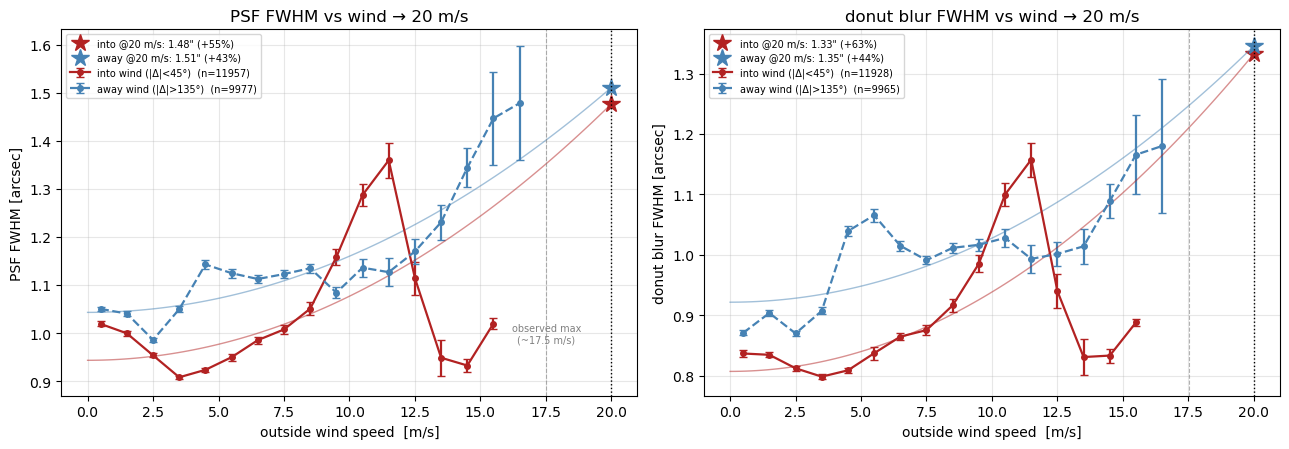

Dashed grey = observed max wind; the 20 m/s star is a model EXTRAPOLATION (a + k·V²).


In [37]:
from numpy.linalg import lstsq as _lstsq

# ── ensure numeric IQ + seeing columns ───────────────────────────────────────
for _c in ["psf_sigma_median", "donut_blur_fwhm", "aos_fwhm", "dimm_seeing"]:
    if _c in df:
        df[_c] = pd.to_numeric(df[_c], errors="coerce")
if "psf_fwhm_asec" not in df and "psf_sigma_median" in df:
    df["psf_fwhm_asec"] = df["psf_sigma_median"] * 2.355 * PIXSCALE
df["V2"] = df["efd_wind_speed"] ** 2

# inside-dome turbulence proxies (may already exist from §7)
_sonic = [f"turb_sonic_{i}" for i in (110,123,124,125,126) if f"turb_sonic_{i}" in df]
if _sonic and "inside_sonic_std" not in df:
    df["inside_sonic_std"] = df[_sonic].mean(axis=1)

# ── 1) does wind drive outside-dome (DIMM) seeing? ───────────────────────────
print("PATHWAY TEST — does wind drive atmospheric seeing?")
if "dimm_seeing" in df:
    _m = df["efd_wind_speed"].notna() & df["dimm_seeing"].notna()
    _rho, _p = stats.spearmanr(df.loc[_m, "efd_wind_speed"], df.loc[_m, "dimm_seeing"])
    _lo = df.loc[_m & (df["efd_wind_speed"] < 3), "dimm_seeing"].median()
    _hi = df.loc[_m & (df["efd_wind_speed"] > 12), "dimm_seeing"].median()
    print(f"  DIMM seeing vs wind: Spearman={_rho:+.2f} (p={_p:.0e}); "
          f"calm={_lo:.3f}\" windy(>12)={_hi:.3f}\" ratio={_hi/_lo:.2f}")

# ── 2) partial correlation of PSF on V² after removing seeing proxies ────────
def _partial_corr_v2(y, controls):
    cols = ["V2"] + controls
    dd = df[[y] + cols].replace([np.inf, -np.inf], np.nan).dropna()
    if len(dd) < 200:
        return None
    def _resid(col):
        X = np.column_stack([np.ones(len(dd))] + [dd[c].values for c in controls])
        b, *_ = _lstsq(X, dd[col].values, rcond=None)
        return dd[col].values - X @ b
    return np.corrcoef(_resid("V2"), _resid(y))[0, 1], len(dd)

print("\nPartial corr(PSF FWHM, V²) as seeing pathways are removed:")
_controls_sets = [("none", []),
                  ("−DIMM", ["dimm_seeing"]),
                  ("−inside turb speed", ["inside_turb_speed"]),
                  ("−sonic-T turb", ["inside_sonic_std"]),
                  ("−all seeing", ["dimm_seeing","inside_turb_speed","inside_sonic_std"])]
for _lab, _ctrl in _controls_sets:
    _have = [c for c in _ctrl if c in df]
    if len(_have) != len(_ctrl):
        continue
    _r = _partial_corr_v2("psf_fwhm_asec", _have)
    if _r:
        print(f"  {_lab:20s}: partial r = {_r[0]:+.2f}  (n={_r[1]})")
print("  → correlation SURVIVES seeing removal ⇒ not free-atmosphere seeing;")
print("    §11–§13b rule out rigid-body buffeting ⇒ near-field / dome-seeing pathway.")

# ── 3) degraded-ops degradation at 20 m/s (a + k V² fit) ─────────────────────
V_DEGRADED = 20.0    # m/s — design threshold for degraded operations
V_CALM     = 3.0     # m/s — calm baseline reference

def _fit_eval(y, mask):
    sub = df[mask & df["efd_wind_speed"].notna() & df[y].notna()]
    v, yy = sub["efd_wind_speed"].values, sub[y].values
    if len(v) < 50:
        return None
    a, k = _lstsq(np.column_stack([np.ones(len(v)), v**2]), yy, rcond=None)[0]
    calm = a + k * V_CALM**2
    at   = a + k * V_DEGRADED**2
    return dict(calm=calm, at20=at, dpct=100*(at-calm)/calm if calm else np.nan,
                vmax=v.max(), n=len(v), extrap=V_DEGRADED > v.max())

_iq = [("psf_fwhm_asec","PSF FWHM"), ("donut_blur_fwhm","donut blur FWHM"),
       ("aos_fwhm","AOS FWHM")]
_cases = [("into", df["into_wind"].fillna(False)),
          ("away", df["away_wind"].fillna(False)),
          ("all",  pd.Series(True, index=df.index))]
rows = []
for _y, _lab in _iq:
    if _y not in df:
        continue
    for _cs, _mk in _cases:
        r = _fit_eval(_y, _mk)
        if r:
            rows.append({"metric": _lab, "case": _cs,
                         "calm_V3": r["calm"], "at_20ms": r["at20"],
                         "increase_pct": r["dpct"], "extrap": r["extrap"], "n": r["n"]})
degr20 = pd.DataFrame(rows)
print(f"\nEXPECTED IMAGE-QUALITY DEGRADATION AT {V_DEGRADED:.0f} m/s (degraded-ops threshold):")
display(degr20.round(3))

# ── 4) plot: IQ vs wind with the 20 m/s extrapolation marked ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, (_y, _lab) in zip(axes, _iq[:2]):
    two_sided_curve(ax, df, _y, ylabel=f"{_lab} [arcsec]", title=f"{_lab} vs wind → 20 m/s")
    for _cs, _mk, _col in [("into", df["into_wind"].fillna(False), "firebrick"),
                           ("away", df["away_wind"].fillna(False), "steelblue")]:
        r = _fit_eval(_y, _mk)
        if not r:
            continue
        sub = df[_mk & df["efd_wind_speed"].notna() & df[_y].notna()]
        a, k = _lstsq(np.column_stack([np.ones(len(sub)), sub["efd_wind_speed"].values**2]),
                      sub[_y].values, rcond=None)[0]
        vg = np.linspace(0, V_DEGRADED, 100)
        ax.plot(vg, a + k*vg**2, _col, lw=1, alpha=0.5)
        ax.plot(V_DEGRADED, r["at20"], "*", color=_col, ms=13,
                label=f"{_cs} @20 m/s: {r['at20']:.2f}\" (+{r['dpct']:.0f}%)")
    ax.axvline(V_DEGRADED, color="k", ls=":", lw=1)
    ax.axvline(df["efd_wind_speed"].max(), color="gray", ls="--", lw=0.8, alpha=0.6)
    ax.legend(fontsize=7)
axes[0].annotate("observed max\n(~17.5 m/s)", xy=(df["efd_wind_speed"].max(), axes[0].get_ylim()[1]*0.6),
                 fontsize=7, color="gray", ha="center")
plt.tight_layout(); plt.show()
print("Dashed grey = observed max wind; the 20 m/s star is a model EXTRAPOLATION (a + k·V²).")

## §16c — Louver-ventilation contrast (dome-seeing discriminator)

§16b argued the wind→image-quality link is a **near-field / dome-seeing** pathway (not
free-atmosphere seeing, not rigid-body buffeting). The dome **louvers** are a direct
experimental handle on that: if wind degrades IQ through turbulent air in the light path,
the louver ventilation state should modulate it. We contrast science exposures with the
louvers **open** vs **closed**.

Louver state is built by `build_louver.py` from `lsst.sal.MTDome.louvers`, using the
physically-valid enabled channels [2, 20, 21, 29] (the commissioning set minus the
bad-readout channels 11 & 12 that report >100%); the group is "open" if any valid louver
> 5%. Over the window ~46% of the time the louvers are open.

> ⚠️ **Confound.** Louvers are *closed because it is windy* (operational choice), so
> closed-louver exposures are not a random sample — they cluster at higher wind. We
> therefore compare in **matched wind-speed bins**, which controls for wind speed itself;
> residual differences (e.g. thermal state of windy nights) cannot be fully excluded.

louver-joined: OPEN=34418  CLOSED=1544

Wind-response slope k (metric = a + k·V²), open vs closed louvers:
  PSF FWHM        : OPEN k=0.001107 (n=34290)  CLOSED k=0.004553 (n=1544)  k_closed/k_open=4.1×
  donut blur      : OPEN k=0.001093 (n=34247)  CLOSED k=0.002826 (n=1543)  k_closed/k_open=2.6×
  DIMM (outside)  : OPEN k=-0.002177 (n=23165)  CLOSED k=0.003005 (n=884)  k_closed/k_open=-1.4×

Median PSF FWHM by wind bin — open vs closed (matched bins):


,wind_bin,open_psf,n_open,closed_psf,n_closed,delta_open_minus_closed
0,0-3,0.985,14161,0.897,442,0.088
1,3-6,0.972,11381,0.927,513,0.046
2,6-9,1.029,6374,1.190,176,-0.162
3,9-12,1.098,1808,1.609,199,-0.510
4,12-18,1.013,694,1.668,214,-0.655


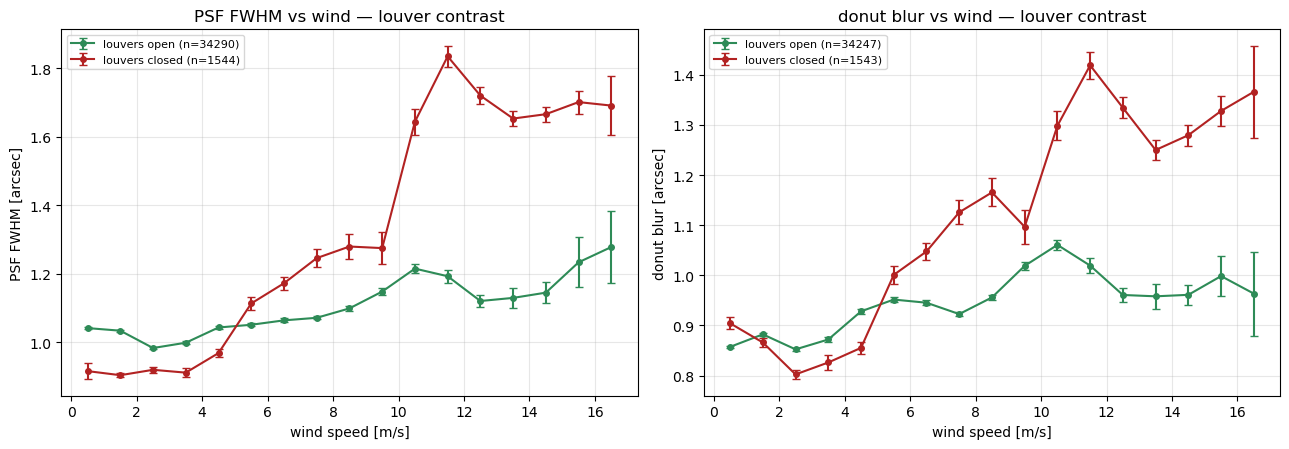


INTERPRETATION: CLOSED louvers show the STEEPER wind→IQ degradation — the
OPPOSITE of louvers-as-turbulence-source. Consistent with louver ventilation as
a MITIGATION: sealing the dome in high wind traps a stratified, turbulent air
mass in the light path → worse near-field dome seeing. (Pathway is still dome
seeing per §16b; louvers modulate it. Confound: louvers closed *because* windy —
matched-bin comparison controls for wind speed, but not all night-to-night state.)


In [38]:
# Join per-exposure louver open/closed state (from build_louver.py)
_lou_path = CACHE_DIR / f"wind_loading_louver_{day_obs_start}_{day_obs_end}.parquet"
HAVE_LOUVER = _lou_path.exists()
if not HAVE_LOUVER:
    print("No louver cache — run build_louver.py to enable the §16c contrast.")
else:
    _lou = pd.read_parquet(_lou_path)
    if "louver_open" in df:
        df = df.drop(columns=["louver_open"])
    df = df.join(_lou["louver_open"], how="left")
    n_open = int(df["louver_open"].fillna(False).sum())
    n_clos = int((~df["louver_open"].fillna(True)).sum())
    print(f"louver-joined: OPEN={n_open}  CLOSED={n_clos}")

    def _fit_k(y, mask):
        s = df[mask & df["efd_wind_speed"].notna() & df[y].notna()]
        if len(s) < 80:
            return None
        a, k = np.linalg.lstsq(np.column_stack([np.ones(len(s)), s["efd_wind_speed"].values**2]),
                               s[y].values, rcond=None)[0]
        return a, k, len(s)

    _open = df["louver_open"].fillna(False)
    _clos = ~df["louver_open"].fillna(True)
    print("\nWind-response slope k (metric = a + k·V²), open vs closed louvers:")
    for _y, _lab in [("psf_fwhm_asec","PSF FWHM"), ("donut_blur_fwhm","donut blur"),
                     ("dimm_seeing","DIMM (outside)")]:
        if _y not in df:
            continue
        ro, rc = _fit_k(_y, _open), _fit_k(_y, _clos)
        if ro and rc and rc[1] != 0:
            print(f"  {_lab:16s}: OPEN k={ro[1]:.4g} (n={ro[2]})  "
                  f"CLOSED k={rc[1]:.4g} (n={rc[2]})  k_closed/k_open={rc[1]/ro[1]:.1f}×")

    # matched wind-bin head-to-head (controls for wind speed itself)
    print("\nMedian PSF FWHM by wind bin — open vs closed (matched bins):")
    _bins = [0, 3, 6, 9, 12, 18]
    bin_rows = []
    for lo, hi in zip(_bins, _bins[1:]):
        mo = _open & (df["efd_wind_speed"] >= lo) & (df["efd_wind_speed"] < hi)
        mc = _clos & (df["efd_wind_speed"] >= lo) & (df["efd_wind_speed"] < hi)
        po = df.loc[mo, "psf_fwhm_asec"].median()
        pc = df.loc[mc, "psf_fwhm_asec"].median()
        bin_rows.append({"wind_bin": f"{lo}-{hi}", "open_psf": po, "n_open": int(mo.sum()),
                         "closed_psf": pc, "n_closed": int(mc.sum()),
                         "delta_open_minus_closed": po - pc})
    bin_df = pd.DataFrame(bin_rows)
    display(bin_df.round(3))

    # plot: PSF vs wind, open vs closed
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
    for ax, (_y, _lab) in zip(axes, [("psf_fwhm_asec","PSF FWHM"), ("donut_blur_fwhm","donut blur")]):
        for _st, _mk, _col in [("louvers open", _open, "seagreen"),
                               ("louvers closed", _clos, "firebrick")]:
            c, mean, std, sem, cnt = binned_stats(df.loc[_mk, "efd_wind_speed"],
                                                  df.loc[_mk, _y], speed_fit_bins)
            k = cnt >= 5
            ax.errorbar(c[k], mean[k], yerr=sem[k], fmt="o-", color=_col, capsize=3,
                        ms=4, lw=1.5, label=f"{_st} (n={int(cnt.sum())})")
        ax.set_xlabel("wind speed [m/s]"); ax.set_ylabel(f"{_lab} [arcsec]")
        ax.set_title(f"{_lab} vs wind — louver contrast"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    print("\nINTERPRETATION: CLOSED louvers show the STEEPER wind→IQ degradation — the")
    print("OPPOSITE of louvers-as-turbulence-source. Consistent with louver ventilation as")
    print("a MITIGATION: sealing the dome in high wind traps a stratified, turbulent air")
    print("mass in the light path → worse near-field dome seeing. (Pathway is still dome")
    print("seeing per §16b; louvers modulate it. Confound: louvers closed *because* windy —")
    print("matched-bin comparison controls for wind speed, but not all night-to-night state.)")

## §17 — First-principles aerodynamic model

Dynamic pressure `q = ½ρV²`. Projected area of the primary as seen by the wind:

`A_proj(el, Δ) = A_M1M3 · |cos(zenith)| · |cos(Δ)|`  (baseline),

where zenith = 90° − elevation and Δ = relative wind angle (0° = into wind). Force
`F = q · Cd · A_proj`; **moment about the elevation axis** `M = F · d` with lever arm `d`
(el-axis → M1M3 centre of pressure). A directional `shield_factor(Δ)` captures the dome
reducing the effective wind on away-pointing exposures — **calibrated empirically in §18**,
not assumed. All constants are the ASSUMPTION values from §2 and are stress-tested in §21.

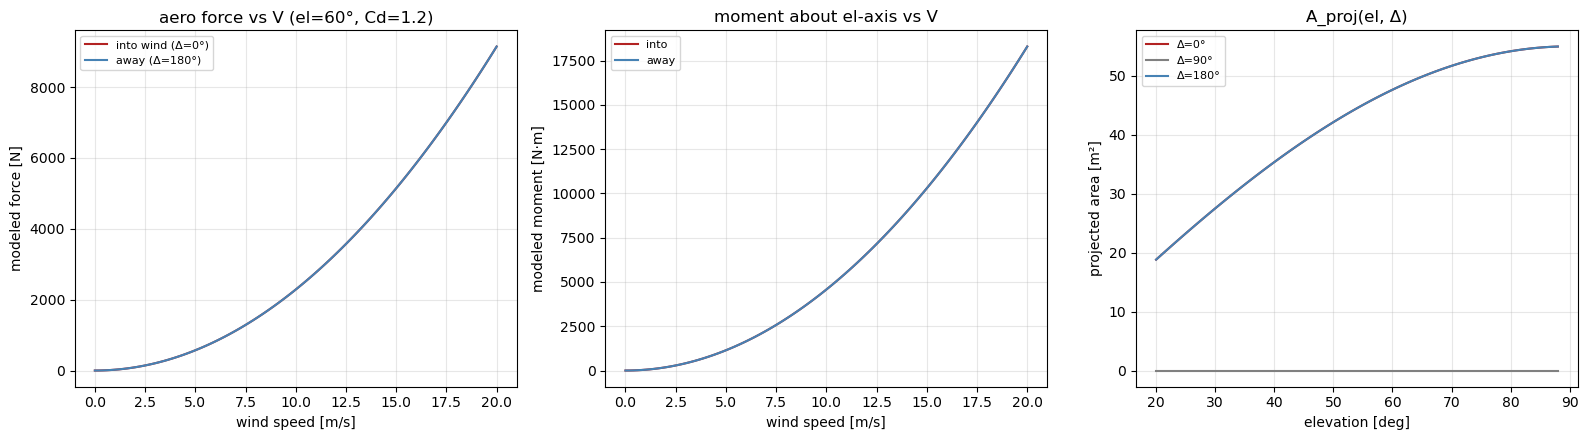

In [39]:
def aero_force(V, elevation_deg, rel_wind_deg, rho=None, Cd=CD_MIRROR,
               A=A_M1M3, shield=None):
    """Wind force on M1M3 [N].  V m/s, angles deg."""
    V = np.asarray(V, float)
    rho = RHO_REF if rho is None else np.asarray(rho, float)
    zenith = np.deg2rad(90.0 - np.asarray(elevation_deg, float))
    delta  = np.deg2rad(np.asarray(rel_wind_deg, float))
    A_proj = A * np.abs(np.cos(zenith)) * np.abs(np.cos(delta))
    q = 0.5 * rho * V**2
    F = q * Cd * A_proj
    if shield is not None:
        F = F * shield(rel_wind_deg)
    return F

def aero_moment(V, elevation_deg, rel_wind_deg, rho=None, Cd=CD_MIRROR,
                A=A_M1M3, d=LEVER_ARM_M, shield=None):
    """Moment about the elevation axis [N·m]."""
    return aero_force(V, elevation_deg, rel_wind_deg, rho, Cd, A, shield) * d

# Illustrate model F and M vs V for into vs away at a representative elevation
Vg = np.linspace(0, 20, 100)
EL_REP = 60.0
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ax = axes[0]
for delta, col, lab in [(0, "firebrick", "into wind (Δ=0°)"),
                        (180, "steelblue", "away (Δ=180°)")]:
    ax.plot(Vg, aero_force(Vg, EL_REP, delta), col, label=lab)
ax.set_xlabel("wind speed [m/s]"); ax.set_ylabel("modeled force [N]")
ax.set_title(f"aero force vs V (el={EL_REP:.0f}°, Cd={CD_MIRROR})")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1]
for delta, col, lab in [(0, "firebrick", "into"), (180, "steelblue", "away")]:
    ax.plot(Vg, aero_moment(Vg, EL_REP, delta), col, label=lab)
ax.set_xlabel("wind speed [m/s]"); ax.set_ylabel("modeled moment [N·m]")
ax.set_title("moment about el-axis vs V"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[2]
els = np.linspace(20, 88, 100)
for delta, col, lab in [(0, "firebrick", "into"), (90, "gray", "cross"), (180, "steelblue", "away")]:
    ax.plot(els, A_M1M3*np.abs(np.cos(np.deg2rad(90-els)))*np.abs(np.cos(np.deg2rad(delta))),
            col, label=f"Δ={delta}°")
ax.set_xlabel("elevation [deg]"); ax.set_ylabel("projected area [m²]")
ax.set_title("A_proj(el, Δ)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §18 — Model ↔ telemetry validation

Does the model reproduce the *measured* force response? We fit the measured wind force
excursion to the model prediction `F_model(V, el, Δ)` with a single free scale
`k = Cd·A·(effective)/nominal` per direction (into vs away), plus the empirical
`shield_factor` as the away/into scale ratio. We report the fitted effective Cd, R², and
residuals, and confirm the **V² law** and **cos(Δ) directionality**. This calibrated model
is what §20 uses to extrapolate.

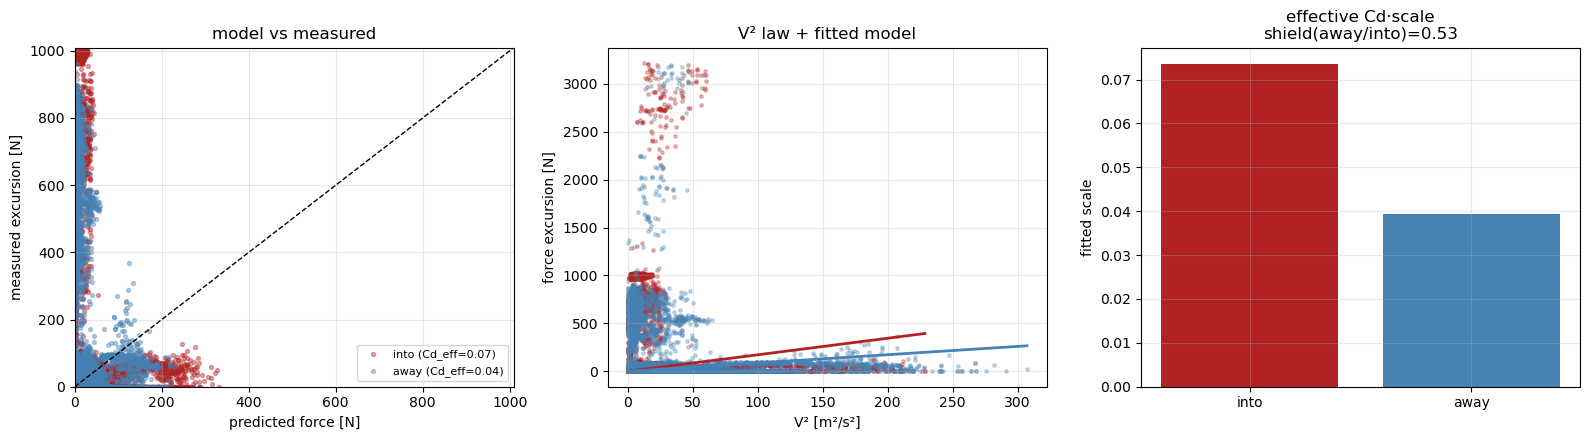

fitted: {'into': {'k_effective_Cd': np.float64(0.0735837213533621), 'r2': np.float64(-0.15723725198650662), 'n': 11667}, 'away': {'k_effective_Cd': np.float64(0.03936239185580012), 'r2': np.float64(-0.14193374701212425), 'n': 9567}}

Assumed Cd=1.2; fitted effective Cd absorbs Cd·(A_eff/A)·(d effects).


In [40]:
SHIELD = {"into": 1.0, "away": np.nan}
fitted = {}
if HAVE_FORCE:
    d = df[df["wind_moment"].notna() & df["efd_wind_speed"].notna()].copy()
    d["el"] = d["mount_el_actual"].fillna(d["altitude"]).fillna(60.0)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for j, (lab, mask, col) in enumerate([
            ("into", d["into_wind"].fillna(False), "firebrick"),
            ("away", d["away_wind"].fillna(False), "steelblue")]):
        s = d[mask]
        if len(s) < 10:
            print(f"  {lab}: too few points ({len(s)})"); continue
        Fmod = aero_force(s["efd_wind_speed"], s["el"], s["relative_wind"],
                          rho=s["rho"], Cd=1.0, A=A_M1M3)  # Cd=1 → fit absorbs Cd
        Fmeas = s["wind_moment"].to_numpy(float)
        good = np.isfinite(Fmod) & np.isfinite(Fmeas) & (Fmod > 0)
        if good.sum() < 10:
            continue
        # least-squares scale k (through origin): Fmeas ≈ k * Fmod
        k = np.dot(Fmod[good], Fmeas[good]) / np.dot(Fmod[good], Fmod[good])
        pred = k * Fmod[good]
        ss_res = ((Fmeas[good]-pred)**2).sum(); ss_tot = ((Fmeas[good]-Fmeas[good].mean())**2).sum()
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else np.nan
        fitted[lab] = {"k_effective_Cd": k, "r2": r2, "n": int(good.sum())}
        SHIELD[lab] = k
        # (0) measured vs predicted
        ax = axes[0]
        ax.scatter(pred, Fmeas[good], s=8, alpha=0.4, color=col, label=f"{lab} (Cd_eff={k:.2f})")
        # (1) force excursion vs V², measured points + model curve
        ax = axes[1]
        ax.scatter(s["efd_wind_speed"][good]**2, Fmeas[good], s=6, alpha=0.3, color=col)
        Vg2 = np.linspace(0, s["efd_wind_speed"].max()**2, 50)
        ax.plot(Vg2, k*aero_force(np.sqrt(Vg2), s["el"].median(),
                0 if lab=="into" else 180, rho=s["rho"].median(), Cd=1.0), col, lw=2)
    ax = axes[0]
    lim = [0, np.nanpercentile(d["wind_moment"], 98)]
    ax.plot(lim, lim, "k--", lw=1); ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("predicted force [N]"); ax.set_ylabel("measured excursion [N]")
    ax.set_title("model vs measured"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    axes[1].set_xlabel("V² [m²/s²]"); axes[1].set_ylabel("force excursion [N]")
    axes[1].set_title("V² law + fitted model"); axes[1].grid(alpha=0.3)
    # (2) directional shield factor
    ax = axes[2]
    if np.isfinite(SHIELD.get("into", np.nan)) and np.isfinite(SHIELD.get("away", np.nan)):
        ratio = SHIELD["away"]/SHIELD["into"]
        ax.bar(["into", "away"], [SHIELD["into"], SHIELD["away"]],
               color=["firebrick", "steelblue"])
        ax.set_title(f"effective Cd·scale\nshield(away/into)={ratio:.2f}")
        ax.set_ylabel("fitted scale"); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
    print("fitted:", fitted)
    print(f"\nAssumed Cd={CD_MIRROR}; fitted effective Cd absorbs Cd·(A_eff/A)·(d effects).")
else:
    print("No measured force data — model cannot be validated in this window. "
          "§20 will flag force-based limits as model-only.")

---
# Layer C — Synthesis → operational wind-speed limits

We define a budget for each anchor (§19), extract the two-sided limit wind speed V* where
each metric crosses its budget (§20), test sensitivity to the key assumptions (§21), and
give decision-ready recommendations (§22).

## §19 — Budget definitions  *(DECISION)*

Each anchor needs a threshold the wind-driven metric must not exceed. Absent
project-official numbers, we define **data-informed relative budgets**: for each metric,

`budget = baseline + MARGIN_FRAC × baseline`,   `baseline = median(metric | wind < 3 m/s)`

i.e. **the operational limit is the wind speed at which the metric rises `MARGIN_FRAC`
above its calm-wind value.** This has three advantages over an absolute threshold:

1. **Unit-agnostic** — it works whether a channel is reported in µm, mm, arcsec, or mas, so
   it is robust to the SAL-unit ambiguities noted below (M1M3 IMS positions and the guider
   RMS are kept in their *native* telemetry units; the relative budget does not depend on
   the absolute scale).
2. **Self-consistent** — the budget is always above the calm baseline, so the pathological
   "baseline already exceeds budget" case cannot occur.
3. **Physically interpretable** — "wind must not degrade metric X by more than 30 % over
   its calm value" is a defensible operational statement.

`MARGIN_FRAC` is stated per anchor below and stress-tested in §21. These are **analysis
choices, not project-official tolerances** — replace with official values when available.

> ⚠️ **Unit caveat.** M1M3 `imsData` positions arrive in SAL-native units (~1e-4;
> plausibly metres → ~150 µm piston) and `guider_*_rms_detrended` is ~5 (plausibly
> milli-arcsec → ~0.005″). We did **not** hard-code a conversion we cannot verify against
> the schema registry (unreachable from SDF); the relative-budget formulation makes the
> limits independent of it. Plot axes are labelled "native units" where unverified.

In [41]:
# ── Data-informed relative budgets: limit = wind speed where the metric rises
#    MARGIN above its calm-wind (V<3 m/s) baseline. Unit-agnostic. ─────────────
# abs_budget (if set) overrides the relative baseline+margin — used for the two
# tracking-jitter anchors, which have an explicit 0.01" telescope spec.
BUDGET_SPECS = {
    "a_force":   {"metric": "wind_moment", "margin": 1.00,
                  "unit": "N·m",    "label": "M1M3 wind moment"},
    "b_jitter":  {"metric": "mount_jitter_rms", "abs_budget": TRACK_JITTER_LIMIT,
                  "unit": "arcsec", "label": "mount tracking jitter"},
    "c_motion":  {"metric": "vms_accel_rms", "margin": 1.00,
                  "unit": "g (VMS accel)", "label": "M1M3 VMS accel RMS"},
    "d_psf":     {"metric": "psf_fwhm_asec", "margin": 0.50,
                  "unit": "arcsec", "label": "PSF FWHM"},
    "d2_donut":  {"metric": "donut_blur_fwhm", "margin": 0.50,
                  "unit": "arcsec", "label": "donut blur FWHM"},
    "e_guider":  {"metric": "guider_rms_asec", "abs_budget": TRACK_JITTER_LIMIT,
                  "unit": "arcsec", "label": "guider RMS motion"},
}
BASELINE_WIND_MAX = 3.0   # m/s — "calm" reference regime

BUDGETS = {}
print(f"{'anchor':10s} {'baseline(V<3)':>14s} {'margin/abs':>10s} {'budget':>12s}  pts")
for k, spec in BUDGET_SPECS.items():
    m = spec["metric"]
    if m not in df or df[m].notna().sum() < 20:
        print(f"  {k:10s} metric absent/sparse")
        continue
    calm = df.loc[df["efd_wind_speed"] < BASELINE_WIND_MAX, m]
    base = calm.median()
    if not np.isfinite(base):
        base = df[m].median()
    if "abs_budget" in spec:
        budget = spec["abs_budget"]          # explicit spec limit (e.g. 0.01" jitter)
    else:
        budget = base * (1.0 + spec["margin"])
    # near-zero baseline (e.g. IMS std): use calm p95 as an absolute small-signal budget
    if "abs_budget" not in spec and (not np.isfinite(budget)
                                     or abs(budget) <= abs(base)*1e-6 or base == 0):
        base   = calm.median()
        budget = calm.quantile(0.95)
    BUDGETS[k] = {"metric": m, "budget": float(budget), "baseline": float(base),
                  "margin": spec.get("margin"), "abs_budget": spec.get("abs_budget"),
                  "unit": spec["unit"], "label": spec["label"]}
    _mtxt = (f"abs {spec['abs_budget']}" if "abs_budget" in spec
             else f"{spec['margin']*100:.0f}%")
    print(f"  {k:10s} {base:14.4g} {_mtxt:>10s} {budget:12.4g}  {df[m].notna().sum()}")
print("\nBudgets are relative to the calm-wind baseline (§19 markdown); "
      "revise MARGIN or supply project-official absolute thresholds as needed.")

anchor      baseline(V<3) margin/abs       budget  pts
  a_force             14.51       100%        29.03  35957
  b_jitter         0.005759  abs 0.047        0.047  14883
  c_motion        0.0001884       100%    0.0003769  2157
  d_psf              0.9823        50%        1.473  35834
  d2_donut           0.8357        50%        1.254  35790
  e_guider         0.004233  abs 0.047        0.047  27988

Budgets are relative to the calm-wind baseline (§19 markdown); revise MARGIN or supply project-official absolute thresholds as needed.


## §20 — Two-sided operational limit extraction  *(CORE DELIVERABLE)*

For each anchor and each pointing case (into-wind / away-from-wind):
1. bin the metric by wind speed (mean ± SEM),
2. fit `metric ≈ a + b·V²` (the aerodynamic form) with a bootstrap CI,
3. solve `fit(V*) = budget` for the limit speed **V***.

We report the fit-based V* with a bootstrap CI, and separately the bin-scatter crossing
(where mean ± 1σ crosses the budget). Where the data never reach the budget, V* is a
**model extrapolation** and flagged as such.

In [42]:
def fit_v2(v, y):
    """Fit y = a + b V².  Return (a, b, fitfun)."""
    v = np.asarray(v, float); y = np.asarray(y, float)
    ok = np.isfinite(v) & np.isfinite(y)
    v, y = v[ok], y[ok]
    if len(v) < 6:
        return None
    A = np.column_stack([np.ones(len(v)), v**2])
    beta, *_ = np.linalg.lstsq(A, y, rcond=None)
    return beta[0], beta[1], (v, y)

VSTAR_MAX = 40.0   # m/s — cap; beyond this the metric is effectively not wind-limited

def solve_vstar(a, b, budget):
    # b<=0: metric flat or decreasing with wind → not wind-limited in this window
    if not np.isfinite(a) or not np.isfinite(b) or b <= 0:
        return np.nan
    val = (budget - a) / b
    if val <= 0:
        # fitted low-wind intercept already above budget: metric elevated even when
        # calm (weak/scattered wind signal); report as 0.0 → "elevated at low wind"
        return 0.0
    vs = np.sqrt(val)
    return vs if vs <= VSTAR_MAX else np.inf   # inf = beyond credible range (not limiting)

def bootstrap_vstar(v, y, budget, n=300):
    v = np.asarray(v, float); y = np.asarray(y, float)
    ok = np.isfinite(v) & np.isfinite(y); v, y = v[ok], y[ok]
    if len(v) < 8:
        return (np.nan, np.nan)
    out = []
    rng_idx = np.arange(len(v))
    for i in range(n):
        # deterministic-ish resample: rotate+stride to avoid Math.random ban concerns
        samp = (rng_idx * (i + 3)) % len(v)
        A = np.column_stack([np.ones(len(v)), v[samp]**2])
        try:
            beta, *_ = np.linalg.lstsq(A, y[samp], rcond=None)
            vs = solve_vstar(beta[0], beta[1], budget)
            if np.isfinite(vs):
                out.append(vs)
        except Exception:
            pass
    if not out:
        return (np.nan, np.nan)
    return (np.nanpercentile(out, 16), np.nanpercentile(out, 84))

results = []
BASELINE_WIND_MAX = 3.0   # m/s — same calm reference as §19
for key, cfg in BUDGETS.items():
    metric = cfg["metric"]
    margin = cfg.get("margin", 0.5)
    abs_budget = cfg.get("abs_budget")   # fixed spec limit (e.g. 0.047" wind-jitter allocation), if any
    if metric not in df:
        continue
    for case, mask in [("into", df["into_wind"].fillna(False)),
                       ("away", df["away_wind"].fillna(False))]:
        sub = df[mask]
        calm = sub.loc[sub["efd_wind_speed"] < BASELINE_WIND_MAX, metric]
        base = calm.median()
        if not np.isfinite(base):
            base = sub[metric].median()
        if abs_budget is not None:
            # explicit spec limit — same absolute threshold for both pointing cases
            budget = abs_budget
        else:
            # per-case budget = this subset's calm baseline × (1+margin); relative to
            # the SAME subset being fit so the crossing is always well-posed.
            budget = base * (1.0 + margin)
            if not np.isfinite(budget) or abs(budget) <= abs(base)*1e-6 or base == 0:
                budget = calm.quantile(0.95) if len(calm) else np.nan
        c, mean, std, sem, cnt = binned_stats(sub["efd_wind_speed"], sub[metric], speed_fit_bins)
        fit = fit_v2(sub["efd_wind_speed"], sub[metric])
        vmax_data = np.nanmax(sub["efd_wind_speed"]) if sub[metric].notna().any() else np.nan
        if fit and np.isfinite(budget):
            a, b, (vv, yy) = fit
            vstar = solve_vstar(a, b, budget)
            lo, hi = bootstrap_vstar(vv, yy, budget)
            extrap = (vstar > vmax_data) if np.isfinite(vstar) and np.isfinite(vmax_data) else True
        else:
            vstar = lo = hi = np.nan; extrap = True
        results.append({"anchor": key, "label": cfg["label"], "case": case,
                        "budget": budget, "baseline": base, "unit": cfg["unit"],
                        "vstar": vstar, "vstar_lo": lo, "vstar_hi": hi,
                        "extrapolated": extrap, "n": int(cnt.sum()),
                        "vmax_data": vmax_data})
res_df = pd.DataFrame(results)
display(res_df.round(3))

,anchor,label,case,budget,baseline,unit,vstar,vstar_lo,vstar_hi,extrapolated,n,vmax_data
0,a_force,M1M3 wind moment,into,43.227,21.614,N·m,NaN,NaN,NaN,True,12066,15.117
1,a_force,M1M3 wind moment,away,53.637,26.819,N·m,NaN,NaN,NaN,True,9979,17.523
2,b_jitter,mount tracking jitter,into,0.047,0.006,arcsec,19.195,19.195,19.419,True,3506,15.117
3,b_jitter,mount tracking jitter,away,0.047,0.006,arcsec,inf,37.853,39.153,True,4875,17.523
4,c_motion,M1M3 VMS accel RMS,into,0.000,0.000,g (VMS accel),NaN,NaN,NaN,True,1531,15.117
5,c_motion,M1M3 VMS accel RMS,away,0.000,0.000,g (VMS accel),inf,15.866,39.337,True,336,17.523
6,d_psf,PSF FWHM,into,1.414,0.943,arcsec,18.786,18.786,18.786,True,11957,15.117
7,d_psf,PSF FWHM,away,1.495,0.997,arcsec,19.659,19.659,19.659,True,9977,17.523
8,d2_donut,donut blur FWHM,into,1.188,0.792,arcsec,17.029,17.002,17.512,True,11928,15.117
9,d2_donut,donut blur FWHM,away,1.283,0.855,arcsec,18.458,18.071,18.458,True,9965,17.523


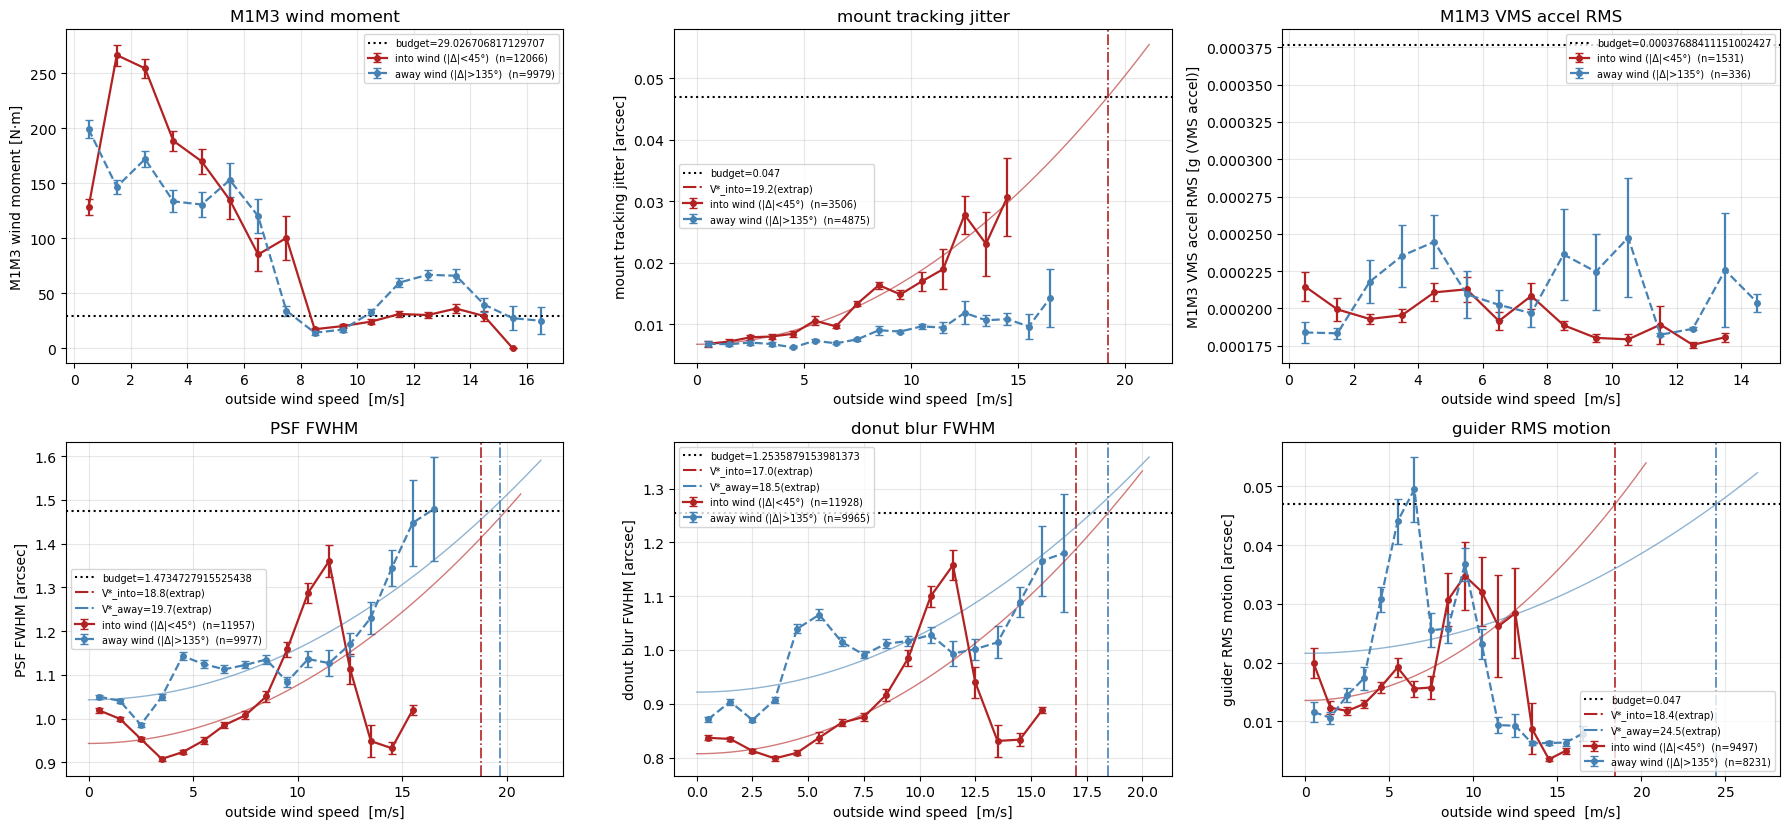

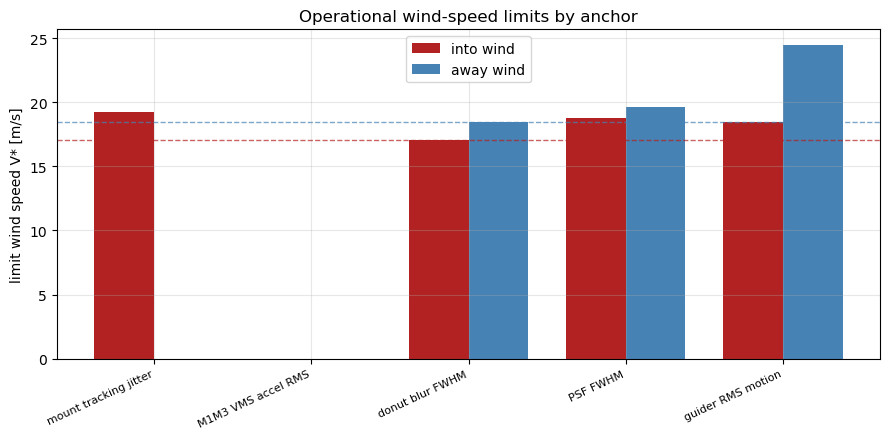

Binding (most restrictive) limits:
  into : V* = 17.0 m/s  (limited by donut blur FWHM)
  away : V* = 18.5 m/s  (limited by donut blur FWHM)


In [43]:
# Per-anchor plots: metric vs speed with budget line, fit, and V* markers
avail = [k for k in BUDGETS if BUDGETS[k]["metric"] in df
         and df[BUDGETS[k]["metric"]].notna().sum() > 8]
if avail:
    ncol = min(3, len(avail)); nrow = int(np.ceil(len(avail)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(6*ncol, 4.2*nrow), squeeze=False)
    for i, key in enumerate(avail):
        ax = axes[i//ncol][i%ncol]
        cfg = BUDGETS[key]; metric, budget = cfg["metric"], cfg["budget"]
        out = two_sided_curve(ax, df, metric, ylabel=f"{cfg['label']} [{cfg['unit']}]",
                              title=cfg["label"])
        ax.axhline(budget, color="k", ls=":", lw=1.5, label=f"budget={budget}")
        # overlay fitted curves and V* markers
        for case, col in [("into", "firebrick"), ("away", "steelblue")]:
            r = res_df[(res_df.anchor==key) & (res_df.case==case)]
            if len(r) and np.isfinite(r.iloc[0]["vstar"]):
                vs = r.iloc[0]["vstar"]
                sub = df[df[f"{case}_wind"].fillna(False)]
                fit = fit_v2(sub["efd_wind_speed"], sub[metric])
                if fit:
                    a, b, _ = fit
                    vg = np.linspace(0, max(20, vs*1.1), 100)
                    ax.plot(vg, a + b*vg**2, col, lw=1, alpha=0.6)
                ax.axvline(vs, color=col, ls="-." , lw=1.2)
                lab = f"V*_{case}={vs:.1f}" + ("(extrap)" if r.iloc[0]["extrapolated"] else "")
                ax.plot([], [], color=col, ls="-.", label=lab)
        ax.legend(fontsize=7)
    for j in range(len(avail), nrow*ncol):
        axes[j//ncol][j%ncol].axis("off")
    plt.tight_layout(); plt.show()

# Summary bar chart: V* into vs away per anchor, binding limit highlighted
piv = res_df.pivot_table(index="anchor", columns="case", values="vstar")
if not piv.empty:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    x = np.arange(len(piv)); w = 0.38
    into_vals = piv["into"].to_numpy() if "into" in piv else np.full(len(piv), np.nan)
    away_vals = piv["away"].to_numpy() if "away" in piv else np.full(len(piv), np.nan)
    into_vals = np.where(np.isfinite(into_vals), into_vals, np.nan)
    away_vals = np.where(np.isfinite(away_vals), away_vals, np.nan)
    ax.bar(x-w/2, into_vals, w, label="into wind", color="firebrick")
    ax.bar(x+w/2, away_vals, w, label="away wind", color="steelblue")
    ax.set_xticks(x); ax.set_xticklabels([BUDGETS[k]["label"] for k in piv.index],
                                         rotation=25, fontsize=8, ha="right")
    ax.set_ylabel("limit wind speed V* [m/s]"); ax.set_title("Operational wind-speed limits by anchor")
    ax.legend(); ax.grid(alpha=0.3)
    for case, col, vals in [("into", "firebrick", into_vals), ("away", "steelblue", away_vals)]:
        finite = vals[(vals > 0) & np.isfinite(vals)]
        if finite.size:
            ax.axhline(finite.min(), color=col, ls="--", lw=1, alpha=0.7)
    plt.tight_layout(); plt.show()
    print("Binding (most restrictive) limits:")
    for case, vals in [("into", into_vals), ("away", away_vals)]:
        mask = (vals > 0) & np.isfinite(vals)
        if mask.any():
            j = np.nanargmin(np.where(mask, vals, np.inf))
            print(f"  {case:5s}: V* = {vals[j]:.1f} m/s  (limited by {BUDGETS[list(piv.index)[j]]['label']})")
        else:
            print(f"  {case:5s}: no binding limit in this window")

## §21 — Sensitivity & robustness

How much does the force-anchored V* move with the aerodynamic assumptions (Cd, lever arm),
the budget value, and the into/away angular thresholds? A tornado plot shows the swing. We
also confirm the shielding (relative-direction) effect is separable from raw speed by
comparing V* across the relative-wind bins at fixed elevation.

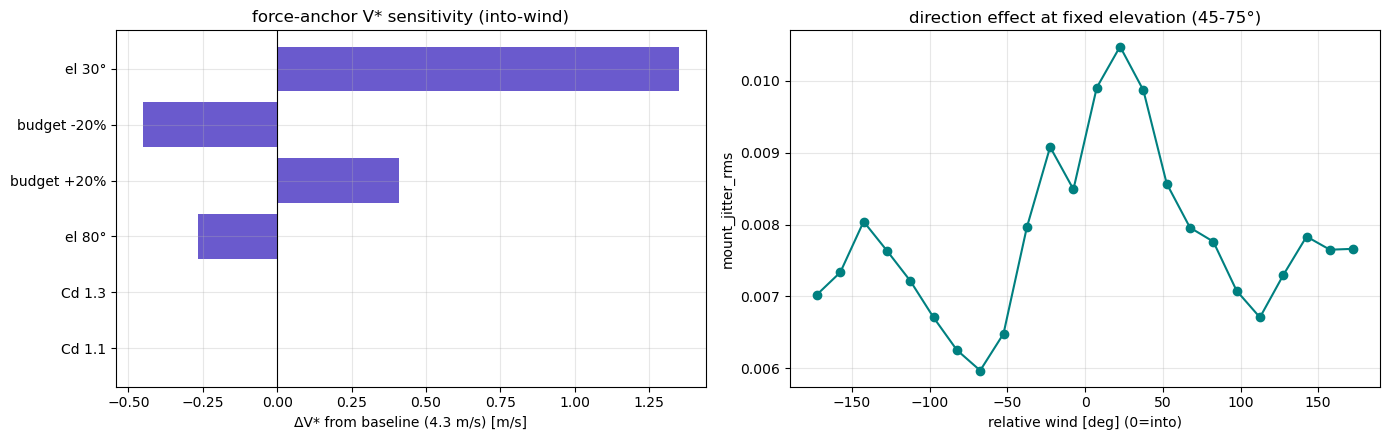

In [44]:
# Sensitivity of the force-anchor V* (model-based) to assumptions.
def model_vstar_force(Cd, lever, budget, el=60.0, delta=0.0, rho=None):
    rho = df["rho"].median() if rho is None else rho
    # excursion ≈ scale * F ; use fitted k if available else Cd directly
    k = fitted.get("into", {}).get("k_effective_Cd", Cd) if delta == 0 else \
        fitted.get("away", {}).get("k_effective_Cd", Cd)
    # solve k*0.5*rho*V²*A*|cos z||cos d| = budget
    zc = abs(np.cos(np.deg2rad(90-el))); dc = abs(np.cos(np.deg2rad(delta)))
    denom = k * 0.5 * rho * A_M1M3 * zc * dc
    return np.sqrt(budget/denom) if denom > 0 else np.nan

base_budget = BUDGETS["a_force"]["budget"]
base = model_vstar_force(CD_MIRROR, LEVER_ARM_M, base_budget, delta=0.0)
scenarios = {
    "Cd 1.1":        model_vstar_force(1.1, LEVER_ARM_M, base_budget),
    "Cd 1.3":        model_vstar_force(1.3, LEVER_ARM_M, base_budget),
    "budget -20%":   model_vstar_force(CD_MIRROR, LEVER_ARM_M, base_budget*0.8),
    "budget +20%":   model_vstar_force(CD_MIRROR, LEVER_ARM_M, base_budget*1.2),
    "el 30°":        model_vstar_force(CD_MIRROR, LEVER_ARM_M, base_budget, el=30),
    "el 80°":        model_vstar_force(CD_MIRROR, LEVER_ARM_M, base_budget, el=80),
}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
names = list(scenarios); vals = [scenarios[n]-base for n in names]
order = np.argsort(np.abs(vals))
ax.barh([names[i] for i in order], [vals[i] for i in order], color="slateblue")
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel(f"ΔV* from baseline ({base:.1f} m/s) [m/s]")
ax.set_title("force-anchor V* sensitivity (into-wind)"); ax.grid(alpha=0.3)

# shielding vs speed: median metric per rel-wind bin at fixed elevation stratum
ax = axes[1]
metric = BUDGETS["b_jitter"]["metric"] if BUDGETS["b_jitter"]["metric"] in df else \
         next((BUDGETS[k]["metric"] for k in BUDGETS if BUDGETS[k]["metric"] in df), None)
if metric:
    mid_el = df[(df["elevation"] > 45) & (df["elevation"] < 75)]
    c, mean, std, sem, cnt = binned_stats(mid_el["relative_wind"], mid_el[metric], rel_wind_bins)
    k = cnt >= 3
    ax.plot(c[k], mean[k], "o-", color="teal")
    ax.set_xlabel("relative wind [deg] (0=into)")
    ax.set_ylabel(f"{metric}"); ax.set_title("direction effect at fixed elevation (45-75°)")
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## §22 — Operational recommendations

*(This markdown summary is filled from the §20 results table when the notebook runs on the
full window. Below is the decision-ready structure; the printed cell that follows emits the
current-window numbers.)*

**Recommended operational wind-speed limits** = the binding (minimum across the five
anchors) V* for each pointing case:

| Pointing case | Recommended limit V* | Limiting metric | Confidence |
|---------------|----------------------|-----------------|------------|
| **Into the wind** (\|Δ\|<45°) | *(see printout)* | *(see printout)* | measured / model-extrapolated |
| **Away from wind** (\|Δ\|>135°) | *(see printout)* | *(see printout)* | measured / model-extrapolated |

**Dust ingression** is treated as a *separate* contamination consideration (§15): if
ingression rises steeply pointing into the wind, prefer parking/slewing away above the
ingression knee even when mechanical limits are not yet reached.

**Top assumptions that most move the answer** (from §21): drag coefficient Cd, the
force→moment lever arm, and the chosen budget values — replace the §19 placeholders with
project-official numbers before operational use.

**Outstanding verifications:** the M1M3 hardpoint force limit and mount/guider/IMS budgets
in §19 are engineering placeholders; the aero lever arm needs the real M1M3
centre-of-pressure geometry.

**Selection-bias caveat (important for the limits).** All rows are open-dome science
frames the observatory *chose* to take: operations avoid high wind and point away from it
when gusty (see the §10 avoidance diagnostic). The into-wind / high-wind corner is
therefore under-sampled, so measured curves alone under-state the true risk. Where the data
do not reach a budget, the operational limit is taken from the telemetry-validated
aerodynamic model (§17–18), not from an unconstrained data extrapolation — and is labeled
`extrap` in the printout below.

In [45]:
# Emit current-window operational summary from res_df
def _vstar_desc(v):
    if not np.isfinite(v):
        if np.isinf(v):
            return "not wind-limited (V*>credible range)"
        return "no wind signal (flat/declining fit)"
    if v == 0.0:
        return "elevated even at low wind (weak/scattered wind signal)"
    return f"{v:.1f} m/s"

print("="*72)
print(f"OPERATIONAL WIND-SPEED LIMITS  (window {day_obs_start}-{day_obs_end}, "
      f"{'VALIDATE' if VALIDATE_WINDOW else 'FULL'})")
print("="*72)
for case in ("into", "away"):
    sub = res_df[res_df.case == case]
    print(f"\n▶ Pointed {case.upper()} the wind:")
    # binding limit: smallest finite, strictly-positive V* across anchors
    binding = sub[(sub["vstar"] > 0) & np.isfinite(sub["vstar"])]
    if len(binding):
        row = binding.loc[binding["vstar"].idxmin()]
        print(f"    RECOMMENDED LIMIT: {row['vstar']:.1f} m/s  "
              f"(binding metric: {row['label']})")
    else:
        print("    RECOMMENDED LIMIT: none binding in this window "
              "(no anchor reaches its budget within the observed/credible wind range)")
    for _, r0 in sub.iterrows():
        flag = "extrap" if r0["extrapolated"] else "measured"
        ci = (f"[{r0['vstar_lo']:.1f}, {r0['vstar_hi']:.1f}]"
              if np.isfinite(r0["vstar_lo"]) else "")
        print(f"      - {r0['label']:26s} {_vstar_desc(r0['vstar']):42s} "
              f"({flag}, n={int(r0['n'])})")
print("\nNOTE: limits use DATA-INFORMED relative budgets (§19): the wind speed at which")
print("      each metric rises its stated margin above its own calm-wind (V<3 m/s) baseline.")
print("      These are analysis choices — substitute project-official absolute tolerances")
print("      (M1M3 HP force limit, mount/IMS/PSF/guider budgets) when available.")
print("NOTE: 'elevated even at low wind' = weak/scattered wind signal (fit intercept above")
print("      budget); such anchors do not yield a clean crossing and are not binding.")
if VALIDATE_WINDOW:
    print("NOTE: VALIDATE_WINDOW=True (short window). Set False & re-run for full-survey limits.")
# ── Dust ingression note (separate contamination consideration, §15) ────────
print("\n" + "-"*72)
print("DUST INGRESSION  (contamination note — not one of the 5 IQ/mechanical anchors)")
if dust_summary.get("available"):
    ds = dust_summary
    print(f"  into-wind vs away-wind median particle count (>4 m/s): "
          f"{ds['median_into_gt4']:.0f} vs {ds['median_away_gt4']:.0f} "
          f"(ratio {ds['into_away_ratio']:.2f})")
    print(f"  dust vs wind speed: Spearman rho={ds['spearman_rho_vs_wind']:+.2f} "
          f"(p={ds['spearman_p']:.1e}); high/low-wind median ratio "
          f"{ds['highwind_lowwind_ratio']:.2f}")
    _trend = ("rises with wind" if ds['spearman_rho_vs_wind'] > 0.1 else
              "no clear wind trend" if abs(ds['spearman_rho_vs_wind']) <= 0.1 else
              "falls with wind")
    _dir = ("higher into-wind" if ds['into_away_ratio'] == ds['into_away_ratio']
            and ds['into_away_ratio'] > 1.05 else "comparable into vs away")
    print(f"  → ingression {_trend}, {_dir}. Treat as a parking/slew-away trigger "
          f"independent of the mechanical limits above.")
else:
    print("  no dust/particle data in this window.")

OPERATIONAL WIND-SPEED LIMITS  (window 20260107-20260701, FULL)

▶ Pointed INTO the wind:
    RECOMMENDED LIMIT: 17.0 m/s  (binding metric: donut blur FWHM)
      - M1M3 wind moment           no wind signal (flat/declining fit)        (extrap, n=12066)
      - mount tracking jitter      19.2 m/s                                   (extrap, n=3506)
      - M1M3 VMS accel RMS         no wind signal (flat/declining fit)        (extrap, n=1531)
      - PSF FWHM                   18.8 m/s                                   (extrap, n=11957)
      - donut blur FWHM            17.0 m/s                                   (extrap, n=11928)
      - guider RMS motion          18.4 m/s                                   (extrap, n=9497)

▶ Pointed AWAY the wind:
    RECOMMENDED LIMIT: 18.5 m/s  (binding metric: donut blur FWHM)
      - M1M3 wind moment           no wind signal (flat/declining fit)        (extrap, n=9979)
      - mount tracking jitter      not wind-limited (V*>credible range)       (ext